# Описание проекта

**Автор:** Костылевская Наталия

**Дата:** 26.06.2026 г.

Анализ производится на данных о бронировании билетов на сервисе Яндекс.Афиша за период с 1 июня по 31 октября 2024 года.

## Цели и задачи:

**Цели:**
- выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года;
- проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

**Задачи:**
- загрузить данные и ознакомиться с ними;
- предобработать данные: проверить их на содержание пропусков, дубликатов, на соответствие типов, а также отфильтровать данные в столбце `revenue` по 99-му процентилю при наличии выбросов и добавить новые столбцы для удобства дальнейшего анализа;
- изучить распределения заказов по сегментам и их сезонные изменения;
- подробно проанализировать активность пользователей осенью 2024 года;
- выделить и рассмотреть ключевые регионы и партнёров осенью 2024 года;
- проверить две гипотезы: 1) среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств; 2) среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств;
- сформулировать общий вывод и рекомендации.

## Описание данных:

Первый датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных и содержит столбцы:
- `order_id` — уникальный идентификатор заказа;
- `user_id` — уникальный идентификатор пользователя;
- `created_dt_msk` — дата создания заказа (московское время);
- `created_ts_msk` — дата и время создания заказа (московское время);
- `event_id` — идентификатор мероприятия из таблицы events;
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет';
- `age_limit` — возрастное ограничение мероприятия;
- `currency_code` — валюта оплаты, например rub для российских рублей;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных;
- `revenue` — выручка от заказа;
- `service_name` — название билетного оператора;
- `tickets_count` — количество купленных билетов;
- `total` — общая сумма заказа;
- `days_since_prev` — количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

Второй датасет `final_tickets_events_df` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Датасет содержит такие поля:
- `event_id` — уникальный идентификатор мероприятия;
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных;
- `event_type_description` — описание типа мероприятия;
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее;
- `organizers` — организаторы мероприятия;
- `region_name` — название региона;
- `city_name` — название города;
- `venue_id` — уникальный идентификатор площадки;
- `venue_name` — название площадки;
- `venue_address` — адрес площадки.

Третий датасет `final_tickets_tenge_df.csv` содержит информацию о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Поля датасета:
- `nominal` — номинал (100 тенге);
- `data` — дата;
- `curs` — курс тенге к рублю;
- `cdx` — обозначение валюты (kzt).

## Структура проекта:

* [1. Загрузка данных и знакомство с ними](#download)
* [2. Предобработка данных и подготовка их к исследованию](#prep)
* [3. Исследовательский анализ данных](#analysis)
    * [Анализ распределения заказов по сегментам и их сезонные изменения](#segments)
    * [Осенняя активность пользователей](#autumn)
    * [Популярные события и партнёры](#popular)
* [4. Статистический анализ данных](#stats)
    * [Среднее количество заказов пользователя по типам устройств](#num)
    * [Среднее время между заказами пользователей по типам устройств](#interval)
* [5. Общий вывод и рекомендации](#summary)


# 1. Загрузка данных и знакомство с ними<a class="anchor" id="download"></a>

Импортируем необходимые для работы библиотеки:

In [1]:
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind

Загрузим данные датасетов и ознакомимся с ними. Датафрейм с информацией о заказах назовем `orders`, с данными о событиях `events`, с курсами валют `exchange`.

In [2]:
orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
exchange = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [3]:
orders.head(5)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  str    
 2   created_dt_msk         290849 non-null  str    
 3   created_ts_msk         290849 non-null  str    
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  str    
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  str    
 8   device_type_canonical  290849 non-null  str    
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  str    
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), str(7)
memory usage: 5

In [5]:
events.head(5)

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   event_id                22427 non-null  int64
 1   event_name              22427 non-null  str  
 2   event_type_description  22427 non-null  str  
 3   event_type_main         22427 non-null  str  
 4   organizers              22427 non-null  str  
 5   region_name             22427 non-null  str  
 6   city_name               22427 non-null  str  
 7   city_id                 22427 non-null  int64
 8   venue_id                22427 non-null  int64
 9   venue_name              22427 non-null  str  
 10  venue_address           22427 non-null  str  
dtypes: int64(3), str(8)
memory usage: 6.8 MB


In [7]:
exchange.head(5)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
exchange.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 15.8 KB


Датафрейм `tickets` не содержит пропусков кроме столбца `days_since_prev`. Содержание пропусков в нем нормально и отображает тот факт, что заказ у пользователя был первым. Столбцы `created_dt_msk` и `created_ts_msk` необходимо будет привести к типам данных, подходящим для работы с датой и временем.

Таблица `events` готова к дальнейшей работе и не содержит пропусков, а типы данных столбцов соответствуют содержимому.

Датафрейм `exchange` также не содержит пропусков, но необходимо изменить тип данных столбца с датой и переименовать столбцы для удобства. Также можно удалить столбцы `nominal` и `cdx` так как во всех строках содержится одно значение.

# 2. Предобработка данных и подготовка их к исследованию<a class="anchor" id="prep"></a>

Переименуем столбцы в датафрейме `exchange`.

In [9]:
exchange.rename(columns={'data': 'date',
                        'curs': 'rate'}, inplace=True)

Приведем данные в столбцах, содержащих информацию о датах, к подходящему типу.

In [10]:
orders[['created_dt_msk', 'created_ts_msk']] = orders[['created_dt_msk', 'created_ts_msk']].astype('datetime64[ns]')

In [11]:
exchange['date'] = exchange['date'].astype('datetime64[ns]')

Объединим таблицы с информацией о заказах и о мероприятиях в рамках датафрейма `orders`.

In [12]:
orders = orders.merge(events, on='event_id', how='left')

Сохраним информацию о количестве строк в получившемся датафрейме.

In [13]:
before_filters = orders.shape[0]
print(f'Строк до фильтрации и обработки дубликатов: {before_filters}')

Строк до фильтрации и обработки дубликатов: 290849


Рассмотрим информацию об объединенной таблице:

In [14]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290849 non-null  int64         
 1   user_id                 290849 non-null  str           
 2   created_dt_msk          290849 non-null  datetime64[ns]
 3   created_ts_msk          290849 non-null  datetime64[ns]
 4   event_id                290849 non-null  int64         
 5   cinema_circuit          290849 non-null  str           
 6   age_limit               290849 non-null  int64         
 7   currency_code           290849 non-null  str           
 8   device_type_canonical   290849 non-null  str           
 9   revenue                 290849 non-null  float64       
 10  service_name            290849 non-null  str           
 11  tickets_count           290849 non-null  int64         
 12  total                   290849 non-null  

Как мы видим, в столбцах, перенесенных из датафрейма `events`, содержатся пропуски. Это говорит о том, что для идентификатора мероприятия `event_id` из таблицы `orders` не нашлось соответствующей строки в таблицы с данными о мероприятиях. Найдем количество таких строк и их долю от всех.

In [15]:
missing_data = orders['event_name'].isna().sum()
missing_share = missing_data / orders.shape[0] * 100
print(f'Строк с пропущенными значениями: {missing_data} ({round(missing_share, 2)}%).')

Строк с пропущенными значениями: 238 (0.08%).


Таких строк меньше 0.1% от всех данных. Их можно удалить без потери точности исследования.

In [16]:
orders = orders[~orders['event_name'].isna()]

Проверим содержимое категориальных столбцов, необходимых для дальнейшего анализа, для поиска скрытых дубликатов (например, различного написания или опечаток).

In [17]:
orders['currency_code'].unique()

<ArrowStringArray>
['rub', 'kzt']
Length: 2, dtype: str

In [18]:
orders['device_type_canonical'].unique()

<ArrowStringArray>
['mobile', 'desktop']
Length: 2, dtype: str

In [19]:
sorted(orders['service_name'].unique())

['Crazy ticket!',
 'Show_ticket',
 'Билет по телефону',
 'Билеты без проблем',
 'Билеты в интернете',
 'Билеты в руки',
 'Быстробилет',
 'Быстрый кассир',
 'Весь в билетах',
 'Восьмёрка',
 'Вперёд!',
 'Выступления.ру',
 'Городской дом культуры',
 'Дом культуры',
 'Дырокол',
 'За билетом!',
 'Зе Бест!',
 'КарандашРУ',
 'Кино билет',
 'Край билетов',
 'Лимоны',
 'Лови билет!',
 'Лучшие билеты',
 'Мир касс',
 'Мой билет',
 'Облачко',
 'Прачечная',
 'Радио ticket',
 'Реестр',
 'Росбилет',
 'Тебе билет!',
 'Телебилет',
 'Тех билет',
 'Цвет и билет',
 'Шоу начинается!',
 'Яблоко']

Названия 'Городской дом культуры' и 'Дом культуры' похожи, но однозначно определить их как дубликаты не представляется возможным. Поэтому было принято решение оставить эти значения неизменными.

In [20]:
orders['event_type_main'].unique()

<ArrowStringArray>
['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Length: 7, dtype: str

In [21]:
sorted(orders['region_name'].unique())

['Белоярская область',
 'Берестовский округ',
 'Берёзовская область',
 'Боровлянский край',
 'Верховинская область',
 'Верхозёрский край',
 'Верхоречная область',
 'Ветренский регион',
 'Вишнёвский край',
 'Глиногорская область',
 'Голубевский округ',
 'Горицветская область',
 'Горноземский регион',
 'Горностепной регион',
 'Дальнеземская область',
 'Дальнезорский край',
 'Дубравная область',
 'Залесский край',
 'Заречная область',
 'Зеленоградский округ',
 'Златопольский округ',
 'Золотоключевской край',
 'Зоринский регион',
 'Каменевский регион',
 'Каменичская область',
 'Каменноозёрный край',
 'Каменноярский край',
 'Каменополянский округ',
 'Ключеводский округ',
 'Кристаловская область',
 'Кристальная область',
 'Крутоводская область',
 'Крутоводский регион',
 'Лесноярский край',
 'Лесодальний край',
 'Лесополянская область',
 'Лесостепной край',
 'Лесоярская область',
 'Луговая область',
 'Лугоградская область',
 'Малиновая область',
 'Малиновоярский округ',
 'Медовская область',


Мы можем наблюдать скрытые дубликаты названий регионов: Крутоводская область и Крутоводский регион, а также Речицкая область и Речицкий регион. Для того, чтобы не потерять данные, заменим в обоих случаях названия с "областей" на "регионы".

In [22]:
orders['region_name'] = orders['region_name'].replace('Крутоводская область', 'Крутоводский регион')
orders['region_name'] = orders['region_name'].replace('Речицкая область', 'Речицкий регион')

Остальные столбцы со строковым содержимым не фигурируют в дальнейшем анализе и потому не нуждаются в проверке. 

Проверим, содержит ли объединенный датафрейм неявные дубликаты (строки, совпадающие по всем столбцам, кроме `order_id`).

In [23]:
dubs = orders.duplicated(subset=[col for col in orders.columns if col != 'order_id'], keep=False)
print(f'Найдено неявных дубликатов: {dubs.sum()}')

Найдено неявных дубликатов: 58


Выведем эти строки:

In [24]:
orders[dubs].sort_values('created_ts_msk', ascending=True)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
232676,7927528,c7a762e320f0def,2024-06-19,2024-06-19 11:07:59,538926,нет,18,rub,mobile,0.00,...,7b378eca-5d03-4f42-9491-a32887424226,событие,другое,№4549,Каменевский регион,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
232673,1585808,c7a762e320f0def,2024-06-19,2024-06-19 11:07:59,538926,нет,18,rub,mobile,0.00,...,7b378eca-5d03-4f42-9491-a32887424226,событие,другое,№4549,Каменевский регион,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
285618,8548070,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:50,489843,нет,18,rub,desktop,989.57,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
285617,8548041,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:50,489843,нет,18,rub,desktop,989.57,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
285622,8547867,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
285615,8548012,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
285614,8547983,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
285612,8547809,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
285619,8548099,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
176438,8248268,8f95286aa5fd8d7,2024-06-20,2024-06-20 10:57:19,244875,нет,0,rub,mobile,15.73,...,61f8b9bd-a66f-4cd9-ae10-a0e62e923476,выставка,другое,№3906,Каменноозёрный край,Ордакент,12.0,2492.0,"Кинофестиваль ""Хранитель"" Инкорпорэйтед","пр. Балтийский, д. 8 к. 51"


Строки совпадают по всем столбцам, кроме нормера заказа. Удалим строки, оставив только первую из дублирующихся.

Удалим эти строки.

In [25]:
orders = orders.drop_duplicates(
    subset=[col for col in orders.columns if col != 'order_id'],
    keep='first'
)

В таблице присутствуют данные о заказах в рублях и тенге. Для того, чтобы это не искажало анализ, приведем значения в столбцах с общей стоимостью заказа и выручкой к рублям и сохраним в новые столбцы: `total_rub` и `revenue_rub`. Для этого используем датафрейм `exchange` с информацией о курсе валют на день заказа.

In [26]:
def exchange_for_rub(df, col):
    if df['currency_code'] == 'rub':
        return df[col]
    else:
        kzt = df[col]
        date = df['created_dt_msk']
        rate_value = exchange[exchange['date'] == date]['rate'].iloc[0]
        return round(kzt / 100 * rate_value, 2)
        
orders['revenue_rub'] = orders.apply(exchange_for_rub, col='revenue', axis=1)
orders['total_rub'] = orders.apply(exchange_for_rub, col='total', axis=1)

Также добавим столбцы со стоимостью одного билета `one_ticket_total_rub` и выручкой с него в рублях `one_ticket_revenue_rub`.

In [27]:
orders['one_ticket_revenue_rub'] = orders['revenue_rub'] / orders['tickets_count']
orders['one_ticket_total_rub'] = orders['total_rub'] / orders['tickets_count']

Создадим столбцы с номером месяца `month` и временем года заказа `season`.

In [28]:
orders['month'] = orders['created_dt_msk'].dt.month

In [29]:
def define_season(df):
    if df['month'] in [1, 2, 12]:
        return 'зима'
    elif df['month'] in [3, 4, 5]:
        return 'весна'
    elif df['month'] in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'
    
orders['season'] = orders.apply(define_season, axis=1)

Проверим результат добавления столбцов, выведя первые пять строк:

In [30]:
orders.head(5)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,revenue_rub,total_rub,one_ticket_revenue_rub,one_ticket_total_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1521.94,10870.99,380.4850,2717.747500,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",289.45,2067.51,144.7250,1033.755000,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.57,13984.16,314.6425,3496.040000,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",8.49,212.28,4.2450,106.140000,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.41,10695.43,463.4700,3565.143333,10,осень


Понизим разрядность числовых данных.

In [31]:
for column in [
    'order_id',
    'event_id',
    'age_limit',
    'tickets_count',
    'month'
]:
    orders[column] = pd.to_numeric(orders[column], downcast='integer', errors='raise')

In [32]:
for column in [
    'revenue',
    'total',
    'days_since_prev',
    'city_id',
    'venue_id',
    'revenue_rub',
    'one_ticket_revenue_rub',
    'one_ticket_total_rub'
]:
    orders[column] = pd.to_numeric(orders[column], downcast='float', errors='raise')

Рассмотрим структуру получившейся таблицы:

In [33]:
orders.info()

<class 'pandas.DataFrame'>
Index: 290581 entries, 0 to 290848
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290581 non-null  int32         
 1   user_id                 290581 non-null  str           
 2   created_dt_msk          290581 non-null  datetime64[ns]
 3   created_ts_msk          290581 non-null  datetime64[ns]
 4   event_id                290581 non-null  int32         
 5   cinema_circuit          290581 non-null  str           
 6   age_limit               290581 non-null  int8          
 7   currency_code           290581 non-null  str           
 8   device_type_canonical   290581 non-null  str           
 9   revenue                 290581 non-null  float64       
 10  service_name            290581 non-null  str           
 11  tickets_count           290581 non-null  int8          
 12  total                   290581 non-null  float

Рассмотрим данные в интересующих нас столбцах `revenue_rub` и `tickets_count` подробнее. Для начала выведем статистику значений в столбце `revenue_rub`:

In [34]:
orders['revenue_rub'].describe()

count    290581.000000
mean        555.594729
std         875.529615
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

Как мы видим, данные имеют большой разброс от -90 до 81174 рублей. Причину появления отрицательных значений мы не знаем, но можно предположить, что такие значения обозначают заказы, по которым был выполнен возврат средств. Среднее значение (555 рублей) заметно превышает медиану (351 рубль), что говорит о наличии выбросов.

Визуализируем распределение значений в столбце при помощи диаграммы размаха (boxplot) и гистограммы.

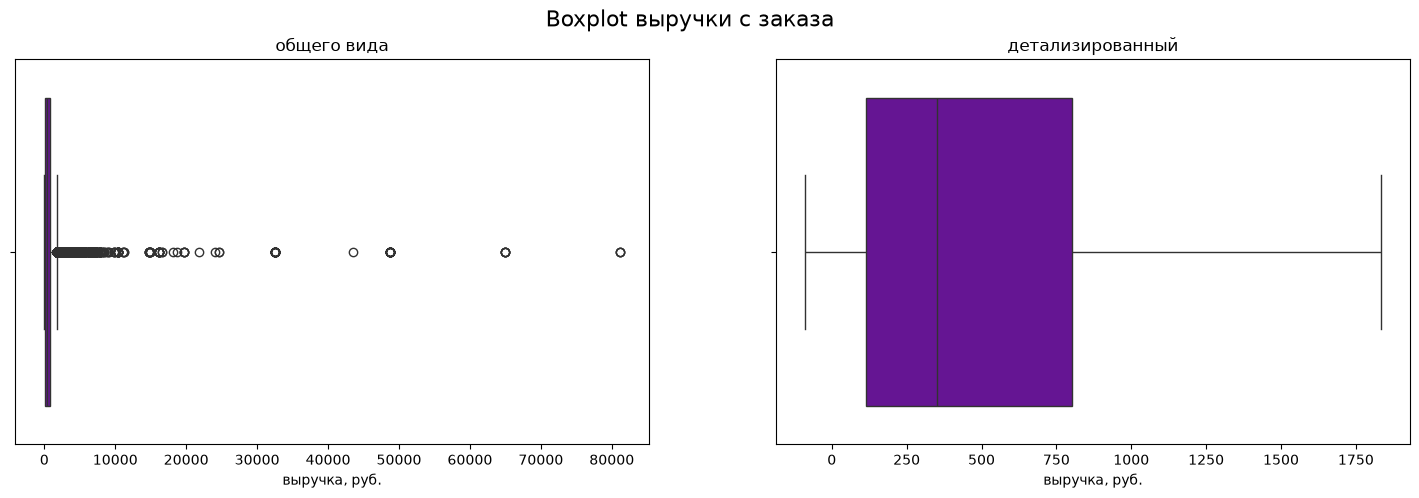

In [35]:
plt.figure(figsize=(18, 5))
plt.suptitle('Boxplot выручки с заказа', fontsize=16)

plt.subplot(1, 2, 1)
orders['dummy'] = 'rand'
sns.boxplot(x='revenue_rub',
            hue='dummy',
            data=orders,
            palette={'rand': cm.plasma(0.2)},
            legend=False)
plt.title('общего вида')
plt.xlabel('выручка, руб.')

plt.subplot(1, 2, 2)
sns.boxplot(x='revenue_rub',
            data=orders,
            hue='dummy',
            showfliers=False,
            palette={'rand': cm.plasma(0.2)},
            legend=False)
plt.title('детализированный')
plt.xlabel('выручка, руб.')

plt.show()

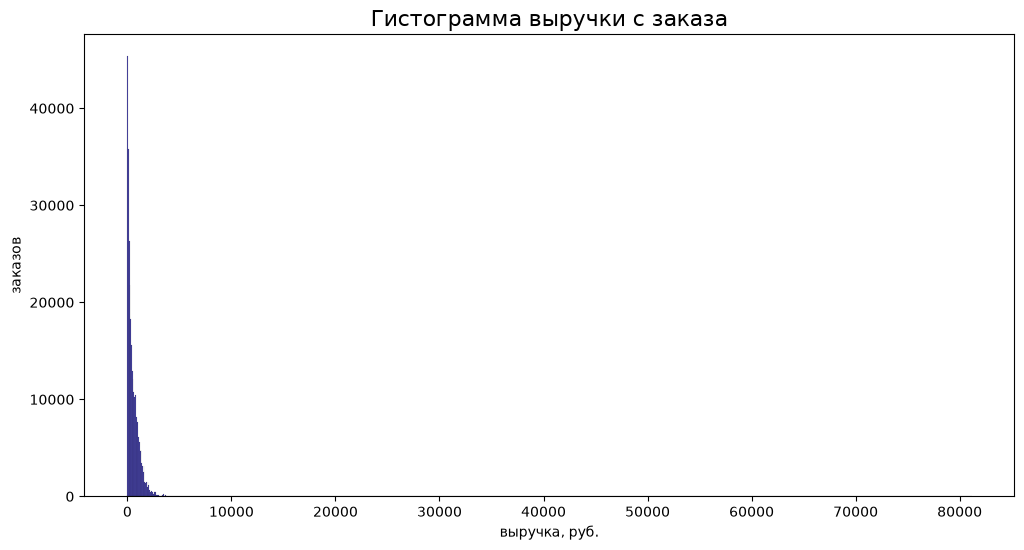

In [36]:
plt.figure(figsize=(12, 6))

sns.histplot(data=orders,
             x='revenue_rub',
             color=cm.plasma(np.linspace(0, 1, 1)))
plt.title('Гистограмма выручки с заказа', fontsize=16)
plt.xlabel('выручка, руб.')
plt.ylabel('заказов')

plt.show()

В значениях выручки с заказа наблюдается большое количество выбросов, причем некоторые из них отстоят от типичных значений чрезвычайно далеко. Чтобы эти единичные экстремальные значения не искажали результаты анализа, отфильтруем их по 99-му процентилю.

In [37]:
orders = orders[orders['revenue_rub'] < orders['revenue_rub'].quantile(0.99)]

Визулизируем распределение значений выручки после фильтрации:

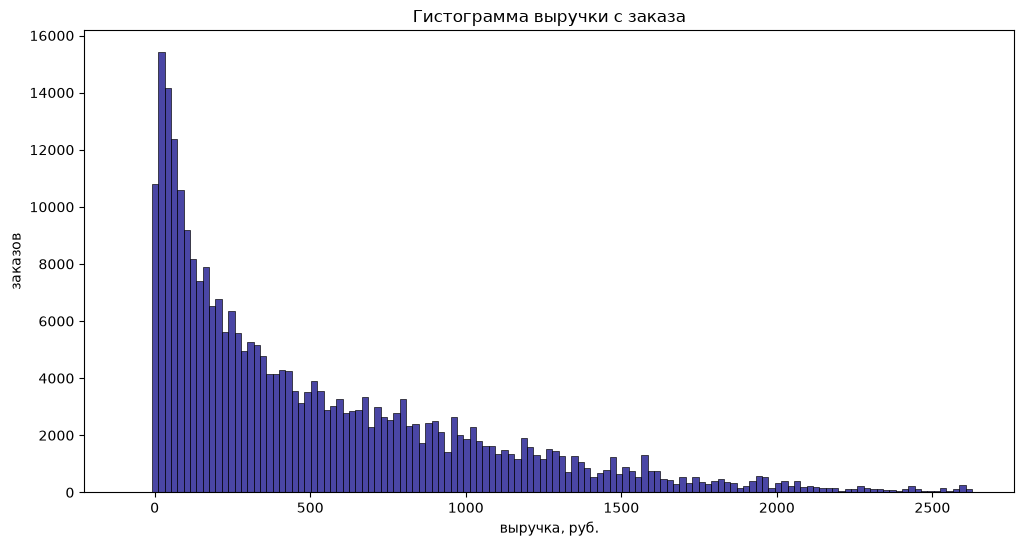

In [38]:
plt.figure(figsize=(12, 6))

sns.histplot(data=orders,
             x='revenue_rub',
             color=cm.plasma(np.linspace(0, 1, 1)))
plt.title('Гистограмма выручки с заказа')
plt.xlabel('выручка, руб.')
plt.ylabel('заказов')

plt.show()

Рассмотрим статистику значений в столбце с количеством билетов в заказе:

In [39]:
orders['tickets_count'].describe()

count    287574.000000
mean          2.740356
std           1.163415
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

Значения в столбце `tickets_count` вполне соответствуют ожидаемым: чаще всего в одном заказе фигурируют 2 или 3 билета, но также встречаются заказы с большим значением (максимальное - 57 билетов). Впрочем, даже с учетом некоторого количества крупных заказов среднее значение (2,74) меньше медианы (3), что говорит о том, что заказов с одним билетом больше, чем заказов с 4+.

Отобразим распределение значений количества билетов в заказе графически:

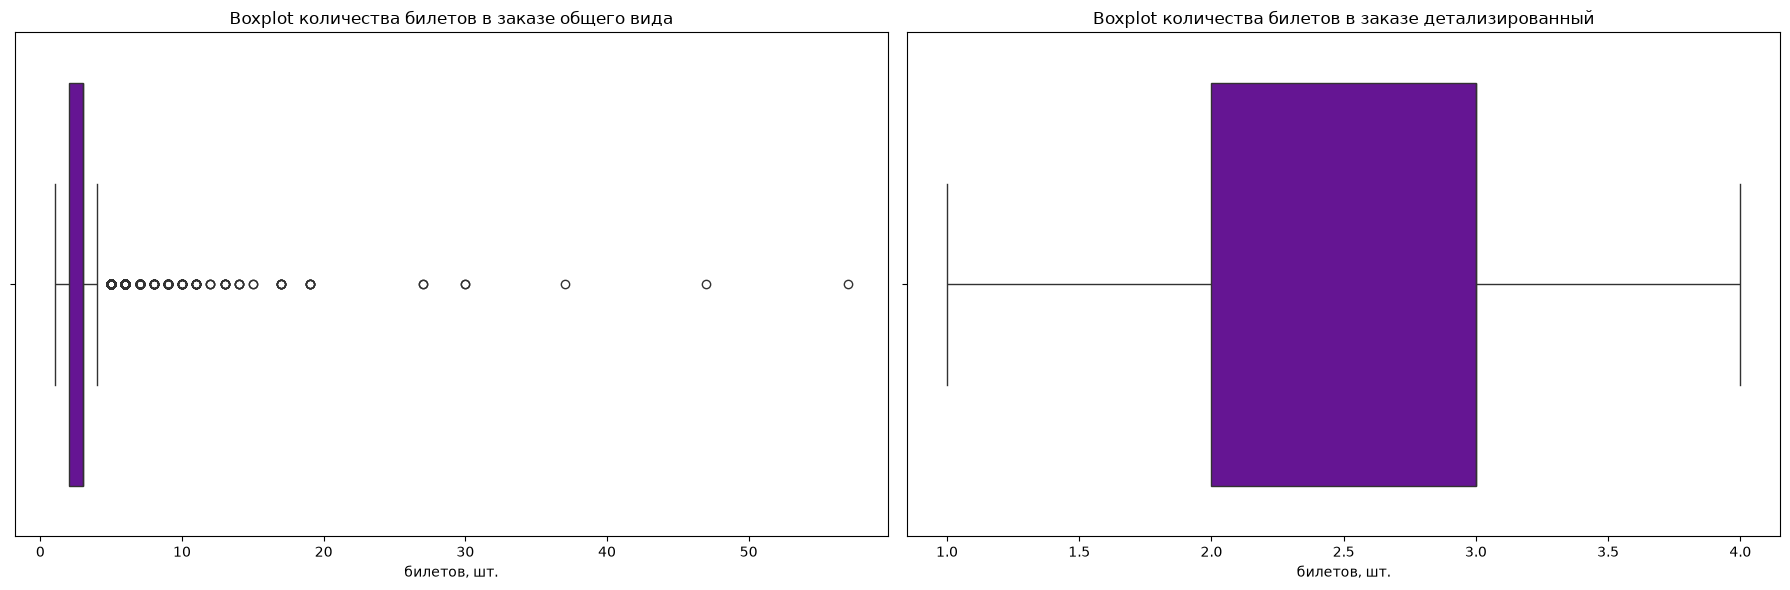

In [40]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='tickets_count',
            hue='dummy',
            data=orders,
            palette={'rand': cm.plasma(0.2)},
            legend=False)
plt.title('Boxplot количества билетов в заказе общего вида')
plt.xlabel('билетов, шт.')

plt.subplot(1, 2, 2)
sns.boxplot(x='tickets_count',
            hue='dummy',
            data=orders,
            showfliers=False, 
            palette={'rand': cm.plasma(0.2)},
            legend=False)
plt.title('Boxplot количества билетов в заказе детализированный')
plt.xlabel('билетов, шт.')

plt.tight_layout()
plt.show()

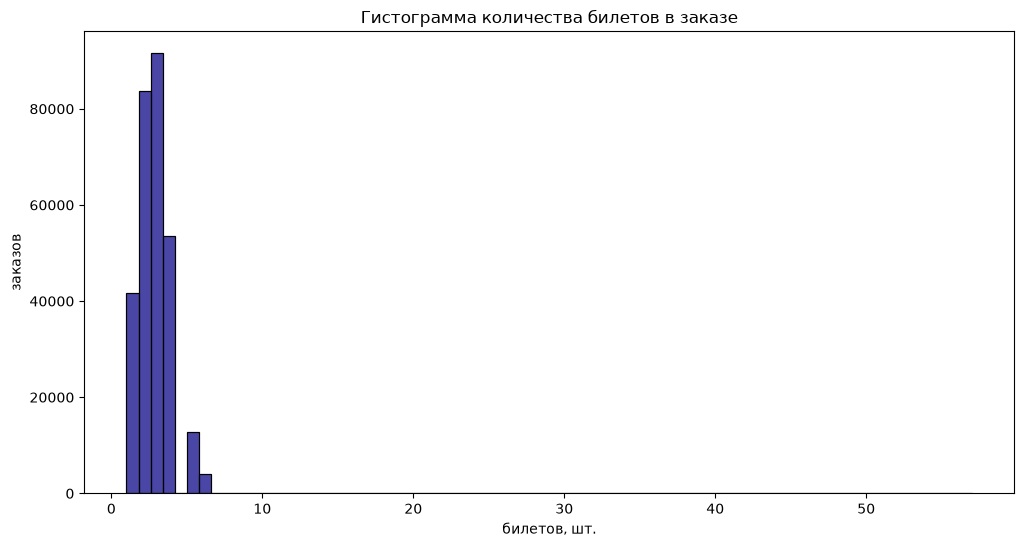

In [41]:
plt.figure(figsize=(12, 6))

sns.histplot(data=orders,
             x='tickets_count',
             bins=70,
             color=cm.plasma(np.linspace(0, 1, 1)))
plt.title('Гистограмма количества билетов в заказе')
plt.xlabel('билетов, шт.')
plt.ylabel('заказов')

plt.show()

Также отфильтруем значения по 99-му процентилю.

In [42]:
orders = orders[orders['revenue_rub'] < orders['revenue_rub'].quantile(0.99)]
after_filters = orders.shape[0]

**Результаты предобработки данных:**

В ходе подготовки данных часть строк была удалена. Причиной стали дубликаты и аномально высокие значения выручки и количества билетов в заказе. Убедимся, что оставшихся после фильтрации данных достаточно:

In [43]:
print(f'По итогу предобработки было удалено {before_filters-after_filters} строк,'
      f'что составило {round((before_filters - after_filters)/before_filters*100, 2)}% исходных данных.')

По итогу предобработки было удалено 6191 строк,что составило 2.13% исходных данных.


Кроме того, были добавлены новые столбцы:
- `revenue_rub` - выручка с заказа в рублях;
- `total_rub` - общая стоимость заказа в рублях;
- `one_ticket_revenue_rub` - выручка с одного билета в рублях;
- `one_ticket_total_rub` - стоимость одного билета в рублях;
- `month` - номер месяца заказа;
- `season` - время года заказа.

Также было проведено преобразование типов данных, а разрядность числовых столбцов была понижена.

Таким образом, данные готовы для дальнейшей работы.

# 3. Исследовательский анализ данных<a class="anchor" id="analisys"></a>

###  Анализ распределения заказов по сегментам и их сезонные изменения<a class="anchor" id="segments"></a>

Предварительно анализ дашборда показал, что в данных наблюдается сезонность — осенью количество заказов увеличивается. Изучим изменение пользовательской активности или пользовательского интереса в связи с сезонностью.

Мы проанализируем динамику по таким разрезам:
- тип мероприятия `event_type_main`;
- тип устройства `device_type_canonical`;
- категория мероприятий по возрастному рейтингу `age_limit`.

Для начала рассмотрим динамику **количества заказов** по месяцам:

In [44]:
months = orders.groupby('month')['order_id'].nunique().reset_index()
months

,month,order_id
0,6,33316
1,7,40036
2,8,44124
3,9,68687
4,10,98495


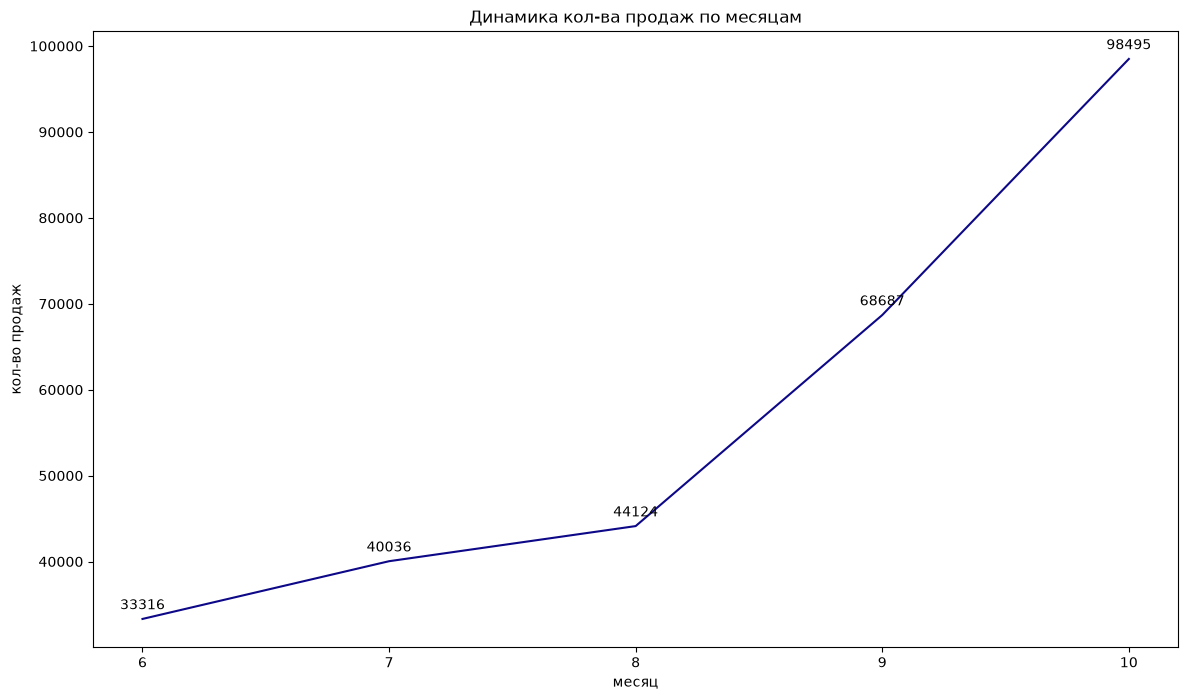

In [45]:
ax = months.plot(
    kind='line',
    x='month',
    y='order_id',
    figsize=(14, 8),
    legend=False,
    title='Динамика кол-ва продаж по месяцам',
    xlabel='месяц',
    ylabel='кол-во продаж',
    color=cm.plasma(np.linspace(0, 1, 1))
)

ax.set_xticks(months['month'])

for i, row in months.iterrows():
    ax.annotate(
        text=f"{row['order_id']}",
        xy=(row['month'], row['order_id']),
        xytext=(0, 7),
        textcoords='offset points',
        ha='center'
    )

plt.show()

Как мы видим, количество заказов стабильно увеличивается на протяжении всего исследуемого периода и за четыре месяца выросло в три раза.

Рассмотрим, как меняются предпочтения пользователей в зависимости от времени года. Для этого подготовим отдельные таблицы с интересующей нас информацией по данным за лето и осень.

In [94]:
autumn = orders[orders['season'] == 'осень']
summer = orders[orders['season'] == 'лето']
autumn_favs = orders[orders['season']=='осень'][['order_id', 'season', 'event_type_main', 'device_type_canonical', 'age_limit', 'one_ticket_revenue_rub']]
summer_favs = orders[orders['season']=='лето'][['order_id', 'season', 'event_type_main', 'device_type_canonical', 'age_limit', 'one_ticket_revenue_rub']]

Изучим **распределение заказов по типам мероприятий** в процентах за лето:

In [95]:
summer_event_type = summer_favs.groupby('event_type_main')['order_id'].count().reset_index()
summer_event_type['order_id'] = (summer_event_type['order_id'] / summer_event_type['order_id'].sum() * 100).round(1)
summer_event_type = summer_event_type.sort_values('order_id', ascending=True)
summer_event_type

,event_type_main,order_id
6,ёлки,0.2
0,выставки,2.1
3,спорт,2.6
4,стендап,5.3
5,театр,20.2
1,другое,27.5
2,концерты,42.1


и осень:

In [96]:
autumn_event_type = autumn_favs.groupby('event_type_main')['order_id'].count().reset_index()
autumn_event_type['order_id'] = (autumn_event_type['order_id'] / autumn_event_type['order_id'].sum() * 100).round(1)
autumn_event_type = autumn_event_type.sort_values('order_id', ascending=True)
autumn_event_type

,event_type_main,order_id
6,ёлки,1.0
0,выставки,1.5
4,стендап,4.1
3,спорт,11.3
1,другое,19.8
5,театр,25.4
2,концерты,36.9


Для большей наглядности визуализируем эти данные:

In [49]:
seasons_ev_types = summer_event_type.merge(
    autumn_event_type, 
    on='event_type_main', 
    suffixes=('_summer', '_autumn')
)
seasons_ev_types = seasons_ev_types.sort_values('order_id_autumn', ascending=True)

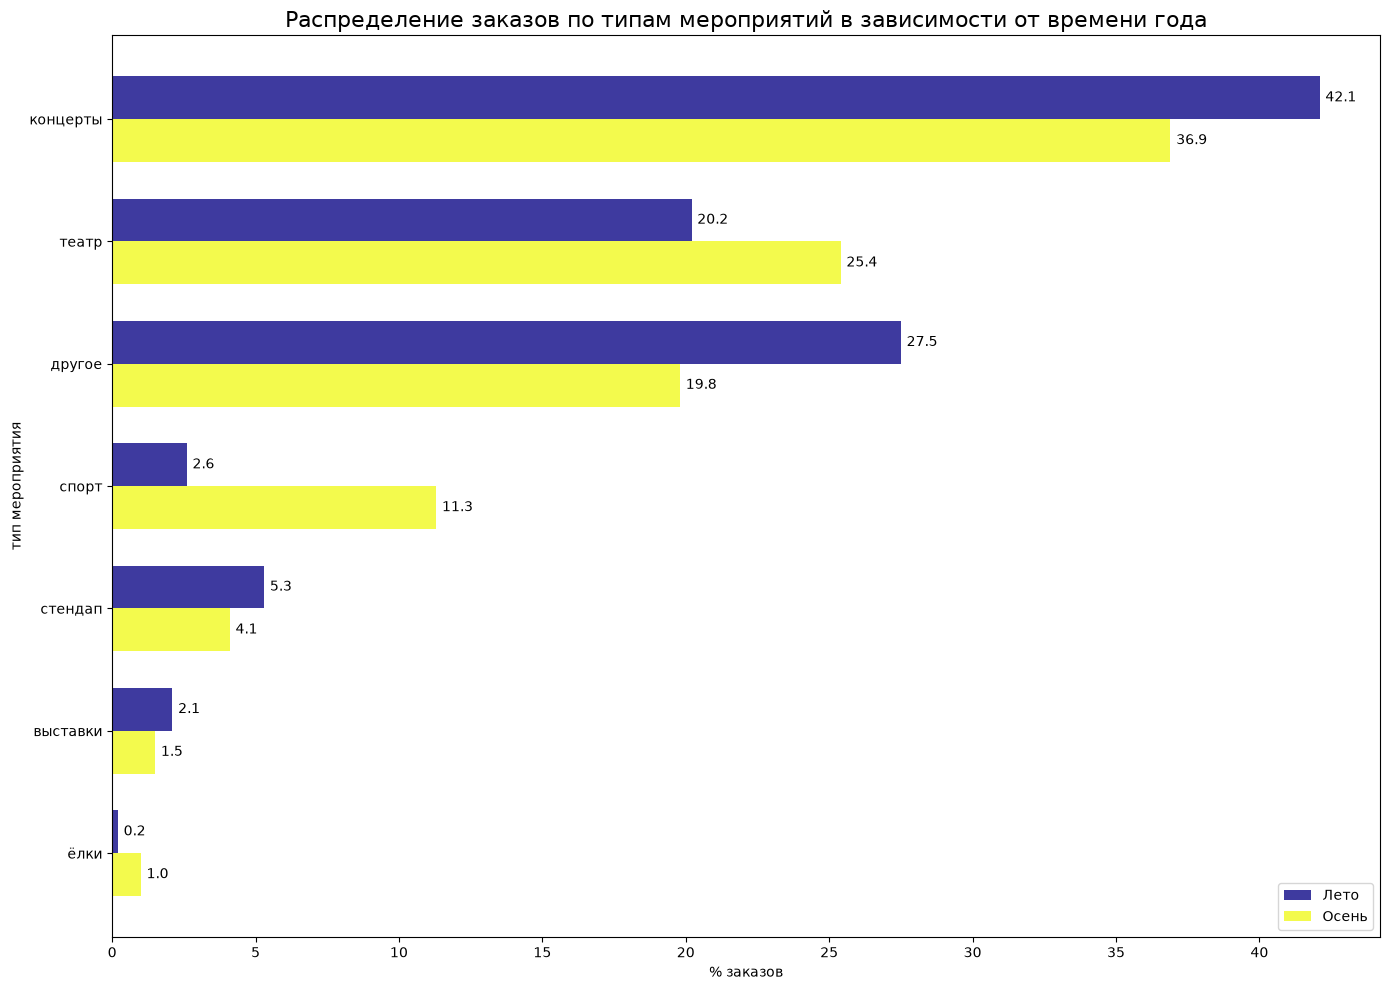

In [50]:
seasons_ev_types = seasons_ev_types.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 10))

y_pos = np.arange(len(seasons_ev_types))
bar_height = 0.35

for i in range(len(seasons_ev_types)):
    ax.barh(y_pos[i] - bar_height/2,
            seasons_ev_types.loc[i, 'order_id_autumn'], 
            height=bar_height,
            color=cm.plasma(np.linspace(1, 0, 2)),
            alpha=0.8)
    
    ax.barh(y_pos[i] + bar_height/2,
            seasons_ev_types.loc[i, 'order_id_summer'], 
            height=bar_height,
            color=cm.plasma(np.linspace(0, 1, 2)),
            alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(seasons_ev_types['event_type_main'])
ax.set_xlabel('% заказов')
ax.set_ylabel('тип мероприятия')
ax.set_title('Распределение заказов по типам мероприятий в зависимости от времени года', fontsize=16)

legend_elements = [
    Patch(facecolor=cm.plasma(np.linspace(0, 1, 2))[0],
          alpha=0.8,
          label='Лето'),
    Patch(facecolor=cm.plasma(np.linspace(1, 0, 2))[0],
          alpha=0.8,
          label='Осень')        
]

for i in range(len(seasons_ev_types)):
    summer_val = seasons_ev_types.loc[i, 'order_id_summer']
    if summer_val > 0:
        ax.text(summer_val + 0.2, y_pos[i] + bar_height/2, 
                f'{summer_val}', va='center')
    
    autumn_val = seasons_ev_types.loc[i, 'order_id_autumn']
    if autumn_val > 0:
        ax.text(autumn_val + 0.2, y_pos[i] - bar_height/2, 
                f'{autumn_val}', va='center')

ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

Несмотря на то, что доля концертов снизилась осенью до 37% против летних 42%, они остались неоспоримым лидером по популярности среди типов мероприятий. Некоторое падение можно связать с погодными условиями: осенью становится рискованным проведение концертов в формате опен-эйр. С третьего на второе место ожидаемо поднялись театральные постановки, что объясняется традиционным затишьем в летний период. Вдвое выросла доля спортивных мероприятий, что можно связать с началом соревновательного периода в наиболее популярных видах спорта, таких, как футбол. Почти на треть снизилась доля покупки билетов на мероприятия, не относящиеся ни к одному из популярных типов.

Узнаем, изменилось ли осенью **распределение количества заказов в разрезе возрастных категорий.**

Для этого подсчитаем процентное соотношение заказов билетов на мероприятия с разными возрастными ограничениями летом:

In [97]:
summer_age_limit = summer_favs.groupby('age_limit')['order_id'].count().reset_index()
summer_age_limit['order_id'] = (summer_age_limit['order_id'] / summer_age_limit['order_id'].sum() * 100).round(1)
summer_age_limit = summer_age_limit.sort_values('order_id', ascending=True)
summer_age_limit

,age_limit,order_id
4,18,15.0
0,0,18.2
1,6,18.2
2,12,20.1
3,16,28.5


и осенью:

In [98]:
autumn_age_limit = autumn_favs.groupby('age_limit')['order_id'].count().reset_index()
autumn_age_limit['order_id'] = (autumn_age_limit['order_id'] / autumn_age_limit['order_id'].sum() * 100).round(1)
autumn_age_limit = autumn_age_limit.sort_values('order_id', ascending=True)
autumn_age_limit

,age_limit,order_id
4,18,10.4
1,6,17.6
2,12,22.0
0,0,23.8
3,16,26.2


Отобразим эту информацию при помощи линейчатой диаграммы:

In [53]:
seasons_limits = summer_age_limit.merge(
    autumn_age_limit, 
    on='age_limit', 
    suffixes=('_summer', '_autumn')
)
seasons_limits = seasons_limits.sort_values('order_id_autumn', ascending=True)

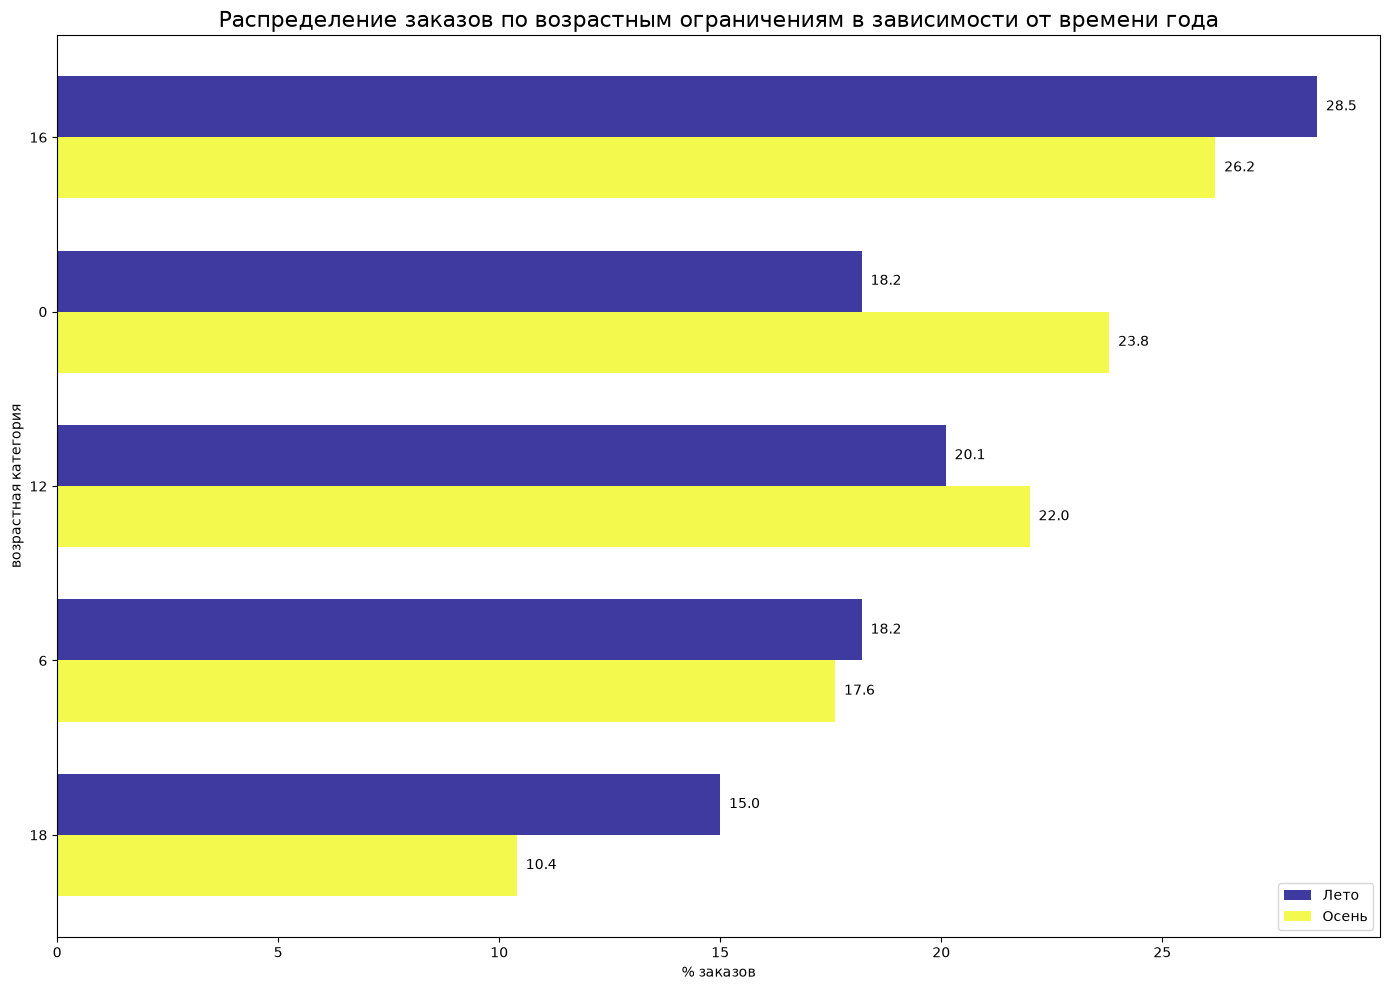

In [54]:
seasons_limits = seasons_limits.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 10))

y_pos = np.arange(len(seasons_limits))
bar_height = 0.35

for i in range(len(seasons_limits)):
    ax.barh(y_pos[i] - bar_height/2,
            seasons_limits.loc[i, 'order_id_autumn'], 
            height=bar_height,
            color=cm.plasma(np.linspace(1, 0, 2)),
            alpha=0.8)
    
    ax.barh(y_pos[i] + bar_height/2,
            seasons_limits.loc[i, 'order_id_summer'], 
            height=bar_height,
            color=cm.plasma(np.linspace(0, 1, 2)),
            alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(seasons_limits['age_limit'])
ax.set_xlabel('% заказов')
ax.set_ylabel('возрастная категория')
ax.set_title('Распределение заказов по возрастным ограничениям в зависимости от времени года', fontsize=16)

legend_elements = [
    Patch(facecolor=cm.plasma(np.linspace(0, 1, 2))[0],
          alpha=0.8,
          label='Лето'),
    Patch(facecolor=cm.plasma(np.linspace(1, 0, 2))[0],
          alpha=0.8,
          label='Осень')        
]

for i in range(len(seasons_limits)):
    summer_val = seasons_limits.loc[i, 'order_id_summer']
    if summer_val > 0:
        ax.text(summer_val + 0.2, y_pos[i] + bar_height/2, 
                f'{summer_val}', va='center')
    
    autumn_val = seasons_limits.loc[i, 'order_id_autumn']
    if autumn_val > 0:
        ax.text(autumn_val + 0.2, y_pos[i] - bar_height/2, 
                f'{autumn_val}', va='center')

ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

В целом можно наблюдать следующую тенденцию: летом доля мероприятий для возрастных групп 16+ и 18+ выше, чем осенью, с наступлением которой растет доля покупки билетов на детские и семейные мероприятия. Это может объясняться в основном окончанием каникул и началом учебного года.

Проверим, изменилось ли осенью **распределение заказов по типам устройств.**

Выведем процентное соотношение для лета и осени:

In [99]:
summer_device = summer_favs.groupby('device_type_canonical')['order_id'].count().reset_index()
summer_device['order_id'] = (summer_device['order_id'] / summer_device['order_id'].sum() * 100).round(1)
summer_device = summer_device.sort_values('order_id', ascending=True)
summer_device

,device_type_canonical,order_id
0,desktop,19.2
1,mobile,80.8


In [100]:
autumn_device = autumn_favs.groupby('device_type_canonical')['order_id'].count().reset_index()
autumn_device['order_id'] = (autumn_device['order_id'] / autumn_device['order_id'].sum() * 100).round(1)
autumn_device = autumn_device.sort_values('order_id', ascending=True)
autumn_device

,device_type_canonical,order_id
0,desktop,20.3
1,mobile,79.7


Наглядно представим это соотношение при помощи круговых диаграмм.

In [57]:
seasons_devices = summer_device.merge(
    autumn_device, 
    on='device_type_canonical', 
    suffixes=('_summer', '_autumn')
)
seasons_devices = seasons_devices.sort_values('order_id_autumn', ascending=True)

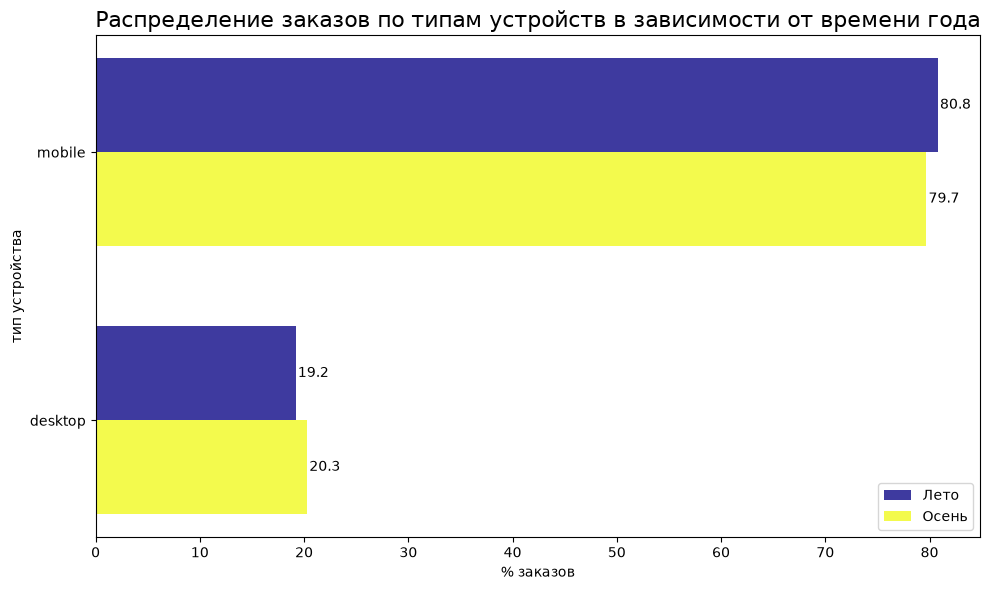

In [58]:
seasons_devices = seasons_devices.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(seasons_devices))
bar_height = 0.35

for i in range(len(seasons_devices)):
    ax.barh(y_pos[i] - bar_height/2,
            seasons_devices.loc[i, 'order_id_autumn'], 
            height=bar_height,
            color=cm.plasma(np.linspace(1, 0, 2)),
            alpha=0.8)
    
    ax.barh(y_pos[i] + bar_height/2,
            seasons_devices.loc[i, 'order_id_summer'], 
            height=bar_height,
            color=cm.plasma(np.linspace(0, 1, 2)),
            alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(seasons_devices['device_type_canonical'])
ax.set_xlabel('% заказов')
ax.set_ylabel('тип устройства')
ax.set_title('Распределение заказов по типам устройств в зависимости от времени года', fontsize=16)

legend_elements = [
    Patch(facecolor=cm.plasma(np.linspace(0, 1, 2))[0],
          alpha=0.8,
          label='Лето'),
    Patch(facecolor=cm.plasma(np.linspace(1, 0, 2))[0],
          alpha=0.8,
          label='Осень')        
]

for i in range(len(seasons_devices)):
    summer_val = seasons_devices.loc[i, 'order_id_summer']
    if summer_val > 0:
        ax.text(summer_val + 0.2, y_pos[i] + bar_height/2, 
                f'{summer_val}', va='center')
    
    autumn_val = seasons_devices.loc[i, 'order_id_autumn']
    if autumn_val > 0:
        ax.text(autumn_val + 0.2, y_pos[i] - bar_height/2, 
                f'{autumn_val}', va='center')

ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

Как мы видим, распределение заказов по типу устройств практически неизменно и подавляющее большинство заказов оформляются с мобильных устройств.

Изучим **изменение выручки с продажи одного билета в зависимости от типа мероприятия** летом и осенью. Для этого создадим таблицу со значениями средней выручки с билета за лето и осень по типам мероприятий и процентным изменением.

In [104]:
ticket_rev_summer = summer_favs.groupby('event_type_main')['one_ticket_revenue_rub'].mean().reset_index()
ticket_rev_summer.rename(columns={'one_ticket_revenue_rub': 'выручка с билета лето'}, inplace=True)
ticket_rev_autumn = autumn_favs.groupby('event_type_main')['one_ticket_revenue_rub'].mean().reset_index()
ticket_rev_autumn.rename(columns={'one_ticket_revenue_rub': 'выручка с билета осень'}, inplace=True)

In [105]:
ticket_rev_seasons = ticket_rev_summer.merge(ticket_rev_autumn, on='event_type_main')
ticket_rev_seasons['динамика'] = (ticket_rev_seasons['выручка с билета осень'] - ticket_rev_seasons['выручка с билета лето']) / ticket_rev_seasons['выручка с билета лето'] * 100
ticket_rev_seasons.rename(columns={'event_type_main': 'тип мероприятия'}, inplace=True)
ticket_rev_seasons

,тип мероприятия,выручка с билета лето,выручка с билета осень,динамика
0,выставки,86.416198,90.603610,4.845634
1,другое,77.262938,75.105488,-2.792348
2,концерты,294.543132,263.010499,-10.705608
3,спорт,50.494488,49.774611,-1.425654
4,стендап,211.713136,228.643611,7.996894
5,театр,211.203525,172.927342,-18.122890
6,ёлки,269.823380,221.377325,-17.954729


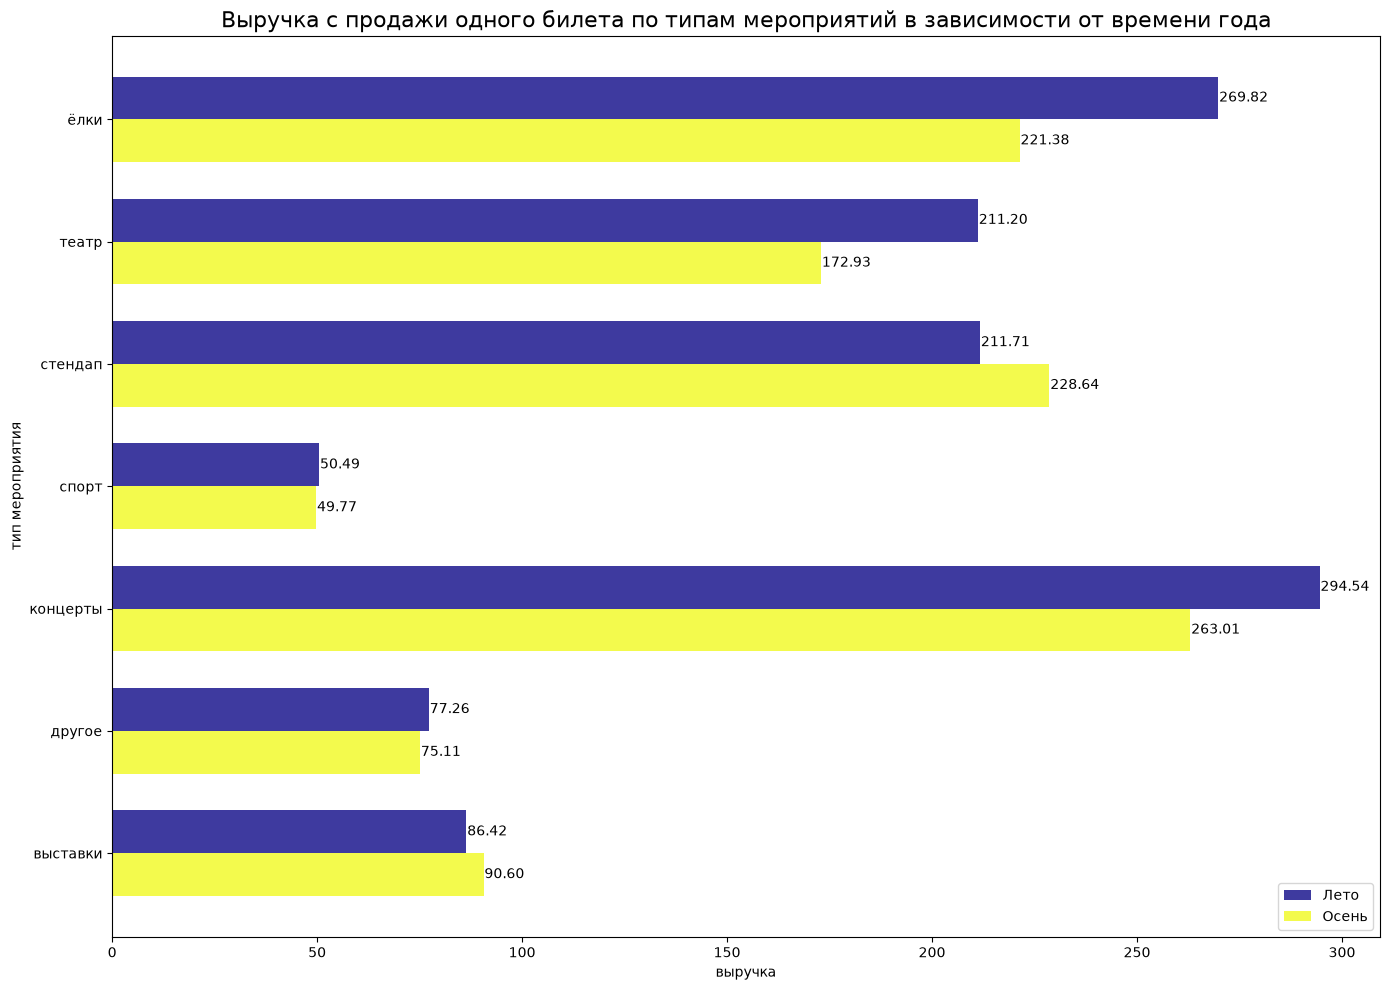

In [61]:
ticket_rev_seasons = ticket_rev_seasons.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 10))

y_pos = np.arange(len(ticket_rev_seasons))
bar_height = 0.35

for i in range(len(ticket_rev_seasons)):
    ax.barh(y_pos[i] - bar_height/2,
            ticket_rev_seasons.loc[i, 'выручка с билета осень'], 
            height=bar_height,
            color=cm.plasma(np.linspace(1, 0, 2)),
            alpha=0.8)
    
    ax.barh(y_pos[i] + bar_height/2,
            ticket_rev_seasons.loc[i, 'выручка с билета лето'], 
            height=bar_height,
            color=cm.plasma(np.linspace(0, 1, 2)),
            alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(ticket_rev_seasons['тип мероприятия'])
ax.set_xlabel('выручка')
ax.set_ylabel('тип мероприятия')
ax.set_title('Выручка с продажи одного билета по типам мероприятий в зависимости от времени года', fontsize=16)

legend_elements = [
    Patch(facecolor=cm.plasma(np.linspace(0, 1, 2))[0],
          alpha=0.8,
          label='Лето'),
    Patch(facecolor=cm.plasma(np.linspace(1, 0, 2))[0],
          alpha=0.8,
          label='Осень')        
]

for i in range(len(ticket_rev_seasons)):
    summer_val = ticket_rev_seasons.loc[i, 'выручка с билета лето']
    if summer_val > 0:
        ax.text(summer_val + 0.2, y_pos[i] + bar_height/2, 
                f'{summer_val:.2f}', va='center')
    
    autumn_val = ticket_rev_seasons.loc[i, 'выручка с билета осень']
    if autumn_val > 0:
        ax.text(autumn_val + 0.2, y_pos[i] - bar_height/2, 
                f'{autumn_val:.2f}', va='center')

ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

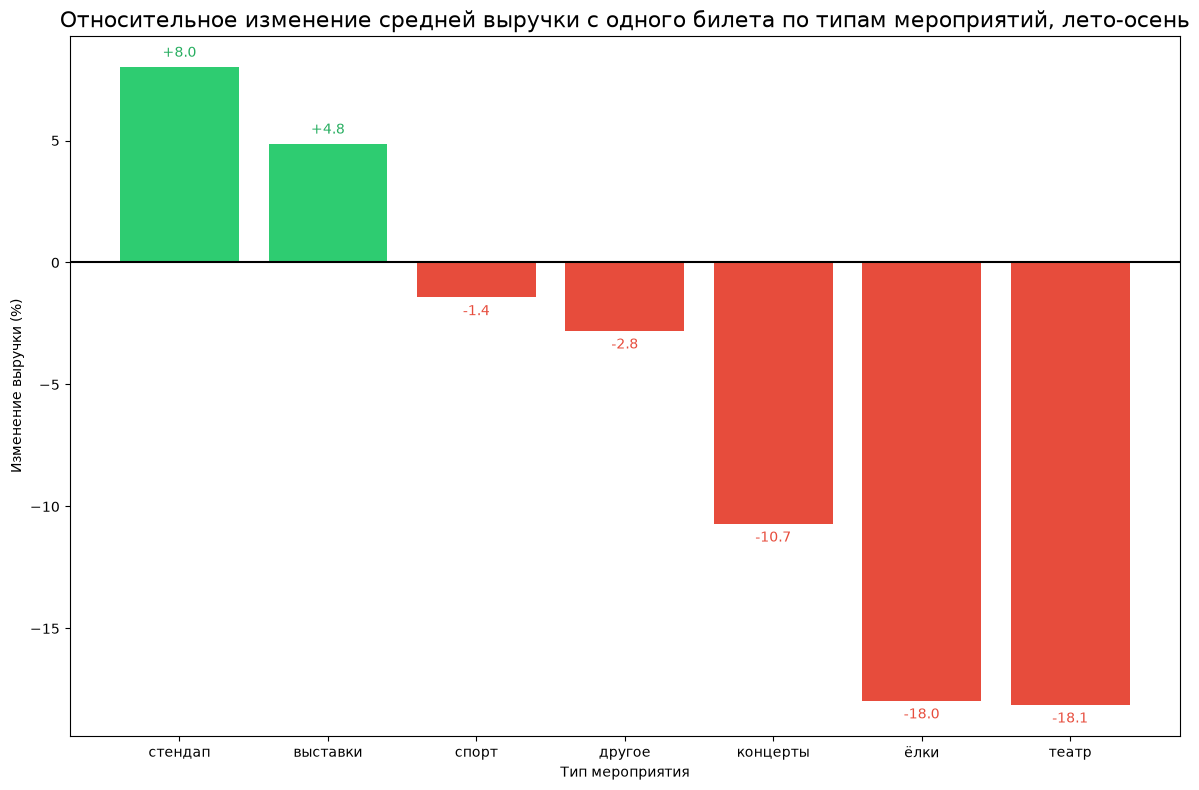

In [62]:
ticket_rev_seasons = ticket_rev_seasons.sort_values('динамика', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

x_pos = np.arange(len(ticket_rev_seasons))

colors = ['#2ECC71' if val >= 0 else '#E74C3C' for val in ticket_rev_seasons['динамика']]

bars = ax.bar(x_pos,
              ticket_rev_seasons['динамика'],
              color=colors)

ax.axhline(y=0, color='black', linestyle='-')

ax.set_xticks(x_pos)
ax.set_xticklabels(ticket_rev_seasons['тип мероприятия'], ha='center')
ax.set_ylabel('Изменение выручки (%)')
ax.set_xlabel('Тип мероприятия')
ax.set_title('Относительное изменение средней выручки с одного билета по типам мероприятий, лето-осень', fontsize=16)

for i, (idx, row) in enumerate(ticket_rev_seasons.iterrows()):
    val = row['динамика']
    if val >= 0:
        ax.text(i, val + 0.3, f'+{val:.1f}', 
                ha='center', va='bottom', color='#27AE60')
    else:
        ax.text(i, val - 0.3, f'{val:.1f}', 
                ha='center', va='top', color='#E74C3C')

plt.tight_layout()
plt.show()

Наиболее значительные изменения в выручке с продажи одного билета показали три категории мероприятий: театр, ёлки и концерты. 

Относительно театральных постановок можно предположить, что более высокая выручка летом обусловлена гастрольным сезоном, когда количество спектаклей может быть сильно ограничено. Кроме того, летом выше доля мероприятий для взрослых, билеты на которые зачастую дороже, чем на детские представления. Также, учитывая рост доли заказов в этой категории и значительный рост заказов в целом, вероятно, свою роль в паделии выручки с билета могли оказать проводимые промокампании для привлечения зрителей с началом театрального сезона.

Относительно елок пока затруднительно говорить о наличие тренда так как сезон активных продаж билетов на новогодние представления еще не наступил и эта категория занимает всего 1% заказов осенью и 0,2% летом.

Причины падения выручки с продажи билетов на концерты неочевидна и требует более глубокого изучения. Можно предположить, что летом было больше популярных концертов с дорогими билетами.

**Промежуточные выводы:**
- присутствует устойчивый тренд к увеличению количества заказов осенью;
- есть умеренно выраженная сезонность относительно популярных видов мероприятий, обусловленная, вероятнее всего, спецификой категории: началом соревновательного сезона в популярных видах спорта осенью и началом театрального сезона;
- осенью возрастает доля заказов на детские и семейные мероприятия, что может быть связано с концом каникул и началом учебного года;
- распределение заказов по типам устройств (мобильные и стационарные) не зависит от сезона;
- некоторые категории мероприятий показывают осенью значительное падение выручки с билета. В случае с театральными постановками это может быть естественным сезонным изменением, учитывая рост заказов в целом и рост популярности категории в частности. Падение выручки с билета в категории концертов требует отдельного изучения с учетом популярности выступающих артистов и площадок.

###  Осенняя активность пользователей<a class="anchor" id="autumn"></a>

Изучим активность пользователей осенью 2024 года.

Для начала проанализируем **динамику изменений по дням** для:
- общего числа заказов;
- количества активных пользователей DAU;
- среднего числа заказов на одного пользователя;
- средней стоимости одного билета.

Подготовим данные за осень и составим сводную таблицу с интересующей нас информацией.

In [106]:
autumn_activity = autumn[['order_id', 'user_id', 'created_dt_msk', 'one_ticket_total_rub']]

In [107]:
autumn_activity['date'] = pd.to_datetime(autumn_activity['created_dt_msk']).dt.date

autumn_daily_pivot = pd.pivot_table(
    data=autumn_activity,
    index='date',
    values=['order_id', 'user_id', 'one_ticket_total_rub'],
    aggfunc={
        'order_id': 'count',
        'user_id': 'nunique',
        'one_ticket_total_rub': 'mean'
    }
).reset_index()

autumn_daily_pivot.columns = ['date', 'avg_ticket_price', 'total_orders', 'dau']

autumn_daily_pivot['avg_orders_per_user'] = autumn_daily_pivot['total_orders'] / autumn_daily_pivot['dau']

autumn_daily_pivot

,date,avg_ticket_price,total_orders,dau,avg_orders_per_user
0,2024-09-01,2239.621349,1302,558,2.333333
1,2024-09-02,2170.078426,1371,572,2.396853
2,2024-09-03,1285.767857,5100,773,6.597671
3,2024-09-04,2132.771765,1757,684,2.568713
4,2024-09-05,2153.751953,1914,733,2.611187
...,...,...,...,...,...
56,2024-10-27,2171.538208,2827,1032,2.739341
57,2024-10-28,1957.414446,2817,985,2.859898
58,2024-10-29,2019.537758,2822,993,2.841893
59,2024-10-30,2103.684412,2904,1037,2.800386


Для наглядности представим эти данные в виде серии линейных графиков:

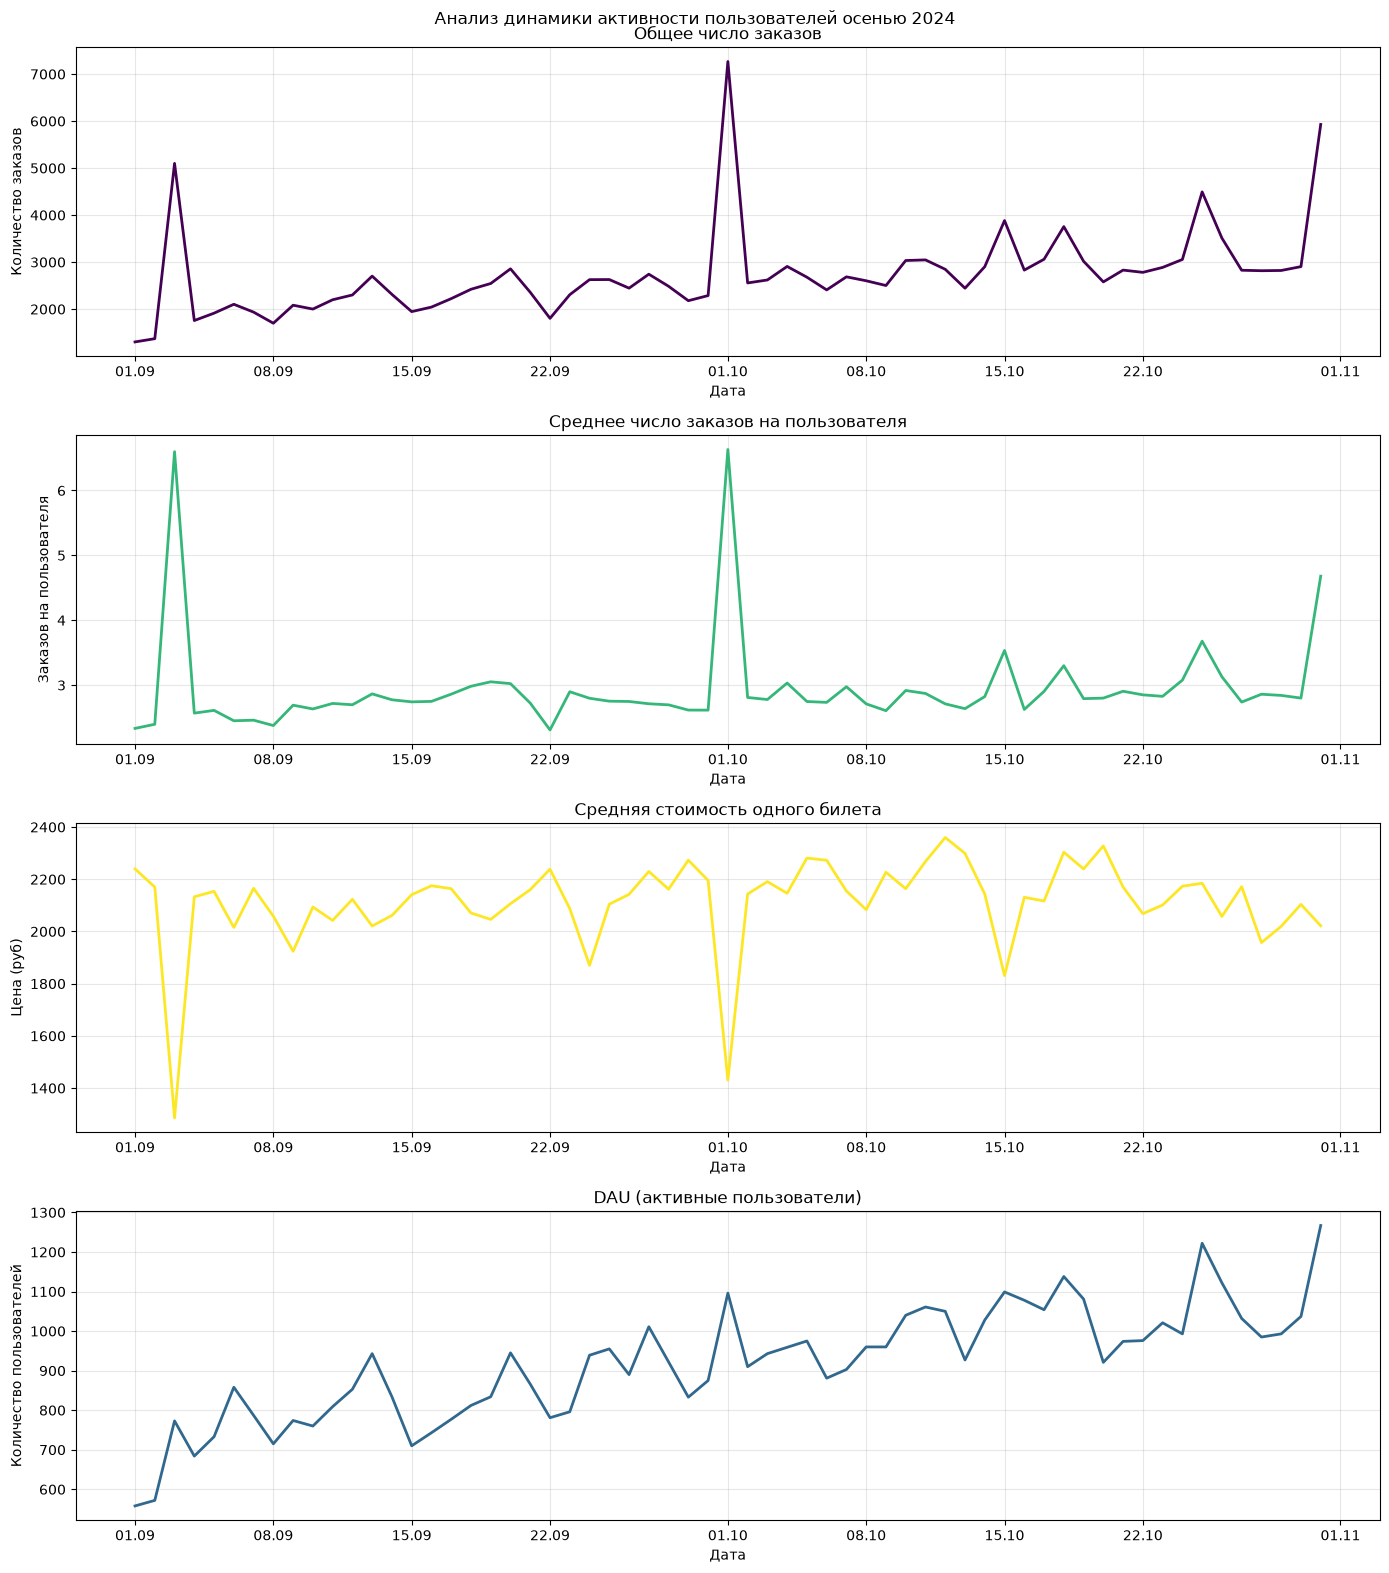

In [108]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

colors = plt.cm.viridis(np.linspace(0, 1, 4))

date_format = mdates.DateFormatter('%d.%m')
date_locator = mdates.AutoDateLocator()

for ax in axes.flat:
    ax.xaxis.set_major_formatter(date_format)
    ax.xaxis.set_major_locator(date_locator)
    ax.tick_params(axis='x')

axes[0].plot(autumn_daily_pivot['date'],
             autumn_daily_pivot['total_orders'],
             linewidth=2,
             color=colors[0])
axes[0].set_title('Общее число заказов')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Количество заказов')
axes[0].grid(True, alpha=0.3)

axes[3].plot(autumn_daily_pivot['date'],
             autumn_daily_pivot['dau'],
             linewidth=2,
             color=colors[1])
axes[3].set_title('DAU (активные пользователи)')
axes[3].set_xlabel('Дата')
axes[3].set_ylabel('Количество пользователей')
axes[3].grid(True, alpha=0.3)

axes[1].plot(autumn_daily_pivot['date'],
             autumn_daily_pivot['avg_orders_per_user'],
             linewidth=2,
             color=colors[2])
axes[1].set_title('Среднее число заказов на пользователя')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Заказов на пользователя')
axes[1].grid(True, alpha=0.3)

axes[2].plot(autumn_daily_pivot['date'],
             autumn_daily_pivot['avg_ticket_price'],
             linewidth=2,
             color=colors[3])
axes[2].set_title('Средняя стоимость одного билета')
axes[2].set_xlabel('Дата')
axes[2].set_ylabel('Цена (руб)')
axes[2].grid(True, alpha=0.3)

fig.suptitle('Анализ динамики активности пользователей осенью 2024')

plt.tight_layout()
plt.show()

Наблюдается очевидная корреляция трех графиков: прямая взаимосвязь числа заказов и среднего числа заказов на пользователя и обратная связь со средней стоимостью билета. Особо выделяются два ика продаж: 3 сентября и 1 октября. В эти дни было сделано большое количество заказов, причем средняя стоимость билетов, купленных в эти дни, была заметно ниже типичной. Таким значениям может быть два объяснения: в эти дни проводились акции/распродажи или открывались продажи билетов на некие чрезвычайно популярные мероприятия и большая часть билетов на них была продана за первый же день.

Стабильно растущее количество активных пользователей говорит о росте популярности сервиса, что подтверждается также и увеличением количества заказов.

**Изучим недельную цикличность.** Выделим день недели и сравните пользовательскую активность.

Для этого агрегируем данные по дням недели, составим сводную таблицу и визуализируем информацию при помощи серии линейных графиков.

In [66]:
autumn_activity['dow'] = pd.to_datetime(autumn_activity['created_dt_msk']).dt.dayofweek

autumn_dow_pivot = pd.pivot_table(
    data=autumn_activity,
    index='dow',
    values=['order_id', 'user_id', 'one_ticket_total_rub'],
    aggfunc={
        'order_id': 'count',
        'user_id': 'nunique',
        'one_ticket_total_rub': 'mean'
    }
).reset_index()

autumn_dow_pivot.columns = ['dow', 'avg_ticket_price', 'total_orders', 'dau']

autumn_dow_pivot['avg_orders_per_user'] = autumn_dow_pivot['total_orders'] / autumn_dow_pivot['dau']

days_ru = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
autumn_dow_pivot['day_of_week_ru'] = autumn_dow_pivot['dow'].map(lambda x: days_ru[x])

autumn_dow_pivot

,dow,avg_ticket_price,total_orders,dau,avg_orders_per_user,day_of_week_ru
0,0,2106.646625,21329,4429,4.815760,Понедельник
1,1,1752.030011,31310,4771,6.562565,Вторник
2,2,2117.689508,22687,4786,4.740284,Среда
3,3,2113.583425,26906,4945,5.441052,Четверг
4,4,2172.105893,24609,4844,5.080306,Пятница
5,5,2186.534986,21149,4545,4.653245,Суббота
6,6,2230.776869,19192,4366,4.395786,Воскресенье


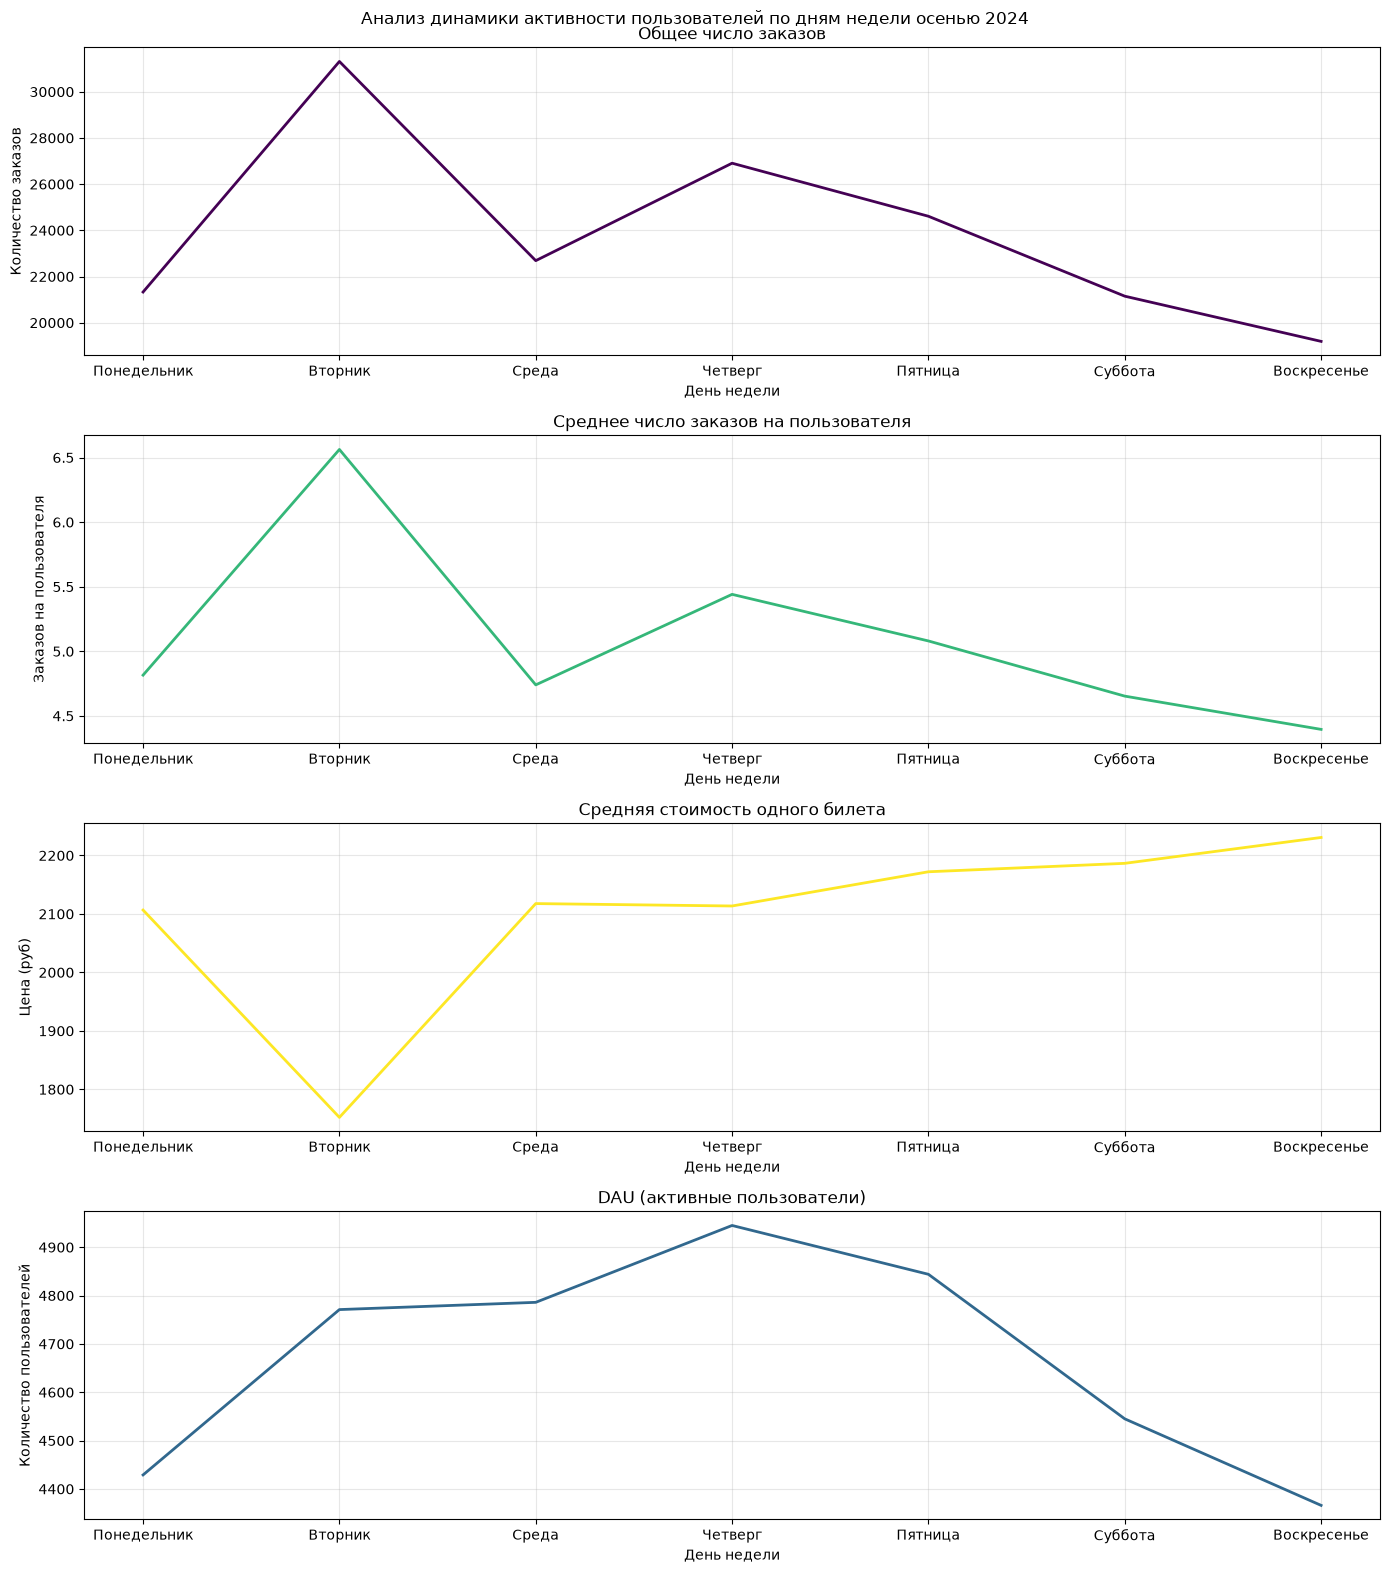

In [67]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

colors = plt.cm.viridis(np.linspace(0, 1, 4))



axes[0].plot(autumn_dow_pivot['day_of_week_ru'],
             autumn_dow_pivot['total_orders'],
             linewidth=2,
             color=colors[0])
axes[0].set_title('Общее число заказов')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Количество заказов')
axes[0].grid(True, alpha=0.3)

axes[3].plot(autumn_dow_pivot['day_of_week_ru'],
             autumn_dow_pivot['dau'],
             linewidth=2,
             color=colors[1])
axes[3].set_title('DAU (активные пользователи)')
axes[3].set_xlabel('День недели')
axes[3].set_ylabel('Количество пользователей')
axes[3].grid(True, alpha=0.3)

axes[1].plot(autumn_dow_pivot['day_of_week_ru'],
             autumn_dow_pivot['avg_orders_per_user'],
             linewidth=2,
             color=colors[2])
axes[1].set_title('Среднее число заказов на пользователя')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Заказов на пользователя')
axes[1].grid(True, alpha=0.3)

axes[2].plot(autumn_dow_pivot['day_of_week_ru'],
             autumn_dow_pivot['avg_ticket_price'],
             linewidth=2,
             color=colors[3])
axes[2].set_title('Средняя стоимость одного билета')
axes[2].set_xlabel('День недели')
axes[2].set_ylabel('Цена (руб)')
axes[2].grid(True, alpha=0.3)

fig.suptitle('Анализ динамики активности пользователей по дням недели осенью 2024')

plt.tight_layout()
plt.show()

На графиках опять наблюдается сильная взаимосвязь общего количества заказов, числа заказов на пользователя и средней стоимости одного билета. Крайние значения во вторник объясняются тем, что популярные мероприятия, продажи билетов на которые начались 3 сентября и 1 октября, о которых мы говорили в предыдущем пункте, сильно влияют на статистику, ведь оба раза пик продаж выпадал на вторник. По этой причине говорить о том, что повышение числа заказов и понижение средней стоимости билета по вторникам является трендом, неверно.

Другой пик числа заказов, совпадающий с пиком числа активных пользователей выпадает на четверг, что можно объяснить подготовкой к выходным и планированием досуга.

На выходных видно падение общего числа заказов, количества заказов на пользователя и числа активных пользователей, что можно объяснить характером пользовательского поведения: чаще всего люди посещают досуговые мероприятия на выходных и вечером в пятницу, а планируют их в будние дни. При этом стоимость билетов, которые заказываются на выходных выше. Этому может быть два объяснения: спонтанные покупки непосредственно перед мероприятием, когда в продаже остались только более дорогие билеты или то, что посещение более дорогостоящих мероприятий планируетсяв среднем за больший срок.

**Промежуточные выводы:**
- популярность сервиса растет, что подтверждается ростом числа активных пользователей осенью;
- за исследуемые два месяца осени дважды открывались продажи билетов на крайне популярные мероприятия: 3 сентября и 1 октября;
- наблюдается недельная цикличность: пользователи активнее пользуются сервисом в период вторник-четверг, а в пятницу-понедельник наблюдается спад пользовательской активности.

###  Популярные события и партнёры<a class="anchor" id="popular"></a>

Рассмотрим, как события распределены по регионам и партнёрам. Это позволит выделить ключевые регионы и партнёров, которые вносят наибольший вклад в выручку.

Сначала для каждого **региона** посчитаем уникальное количество мероприятий и общее число заказов, а также долю мероприятий и заказов от всех.

Выведем топ-10 регионом по доле событий:

In [68]:
total_events_num = orders['event_id'].nunique()
total_orders_num = orders['order_id'].nunique()
total_revenue_num = orders['revenue_rub'].sum()

In [69]:
region_events = orders.groupby('region_name').agg({
    'event_id': 'nunique',
    'order_id': 'nunique'
}).reset_index()
region_events['event_share'] = round(region_events['event_id'] / total_events_num * 100, 1)
region_events['order_share'] = round(region_events['order_id'] / total_orders_num * 100, 1)
region_events.sort_values(by='event_share', ascending=False, inplace=True)
region_events.head(10)

,region_name,event_id,order_id,event_share,order_share
23,Каменевский регион,5908,88472,26.5,31.1
58,Североярская область,3789,43385,17.0,15.2
75,Широковская область,1232,15975,5.5,5.6
55,Светополянский округ,1075,7429,4.8,2.6
51,Речиновская область,701,6220,3.1,2.2
72,Травяная область,683,5017,3.1,1.8
11,Горицветская область,550,5138,2.5,1.8
76,Яблоневская область,535,6028,2.4,2.1
67,Тепляковская область,527,4379,2.4,1.5
59,Серебринская область,541,5553,2.4,2.0


Как мы можем наблюдать, 43,6% всех мероприятий прошли в двух регионах: Каменевском регионе и Североярской области. Более 1000 мероприятий прошли также в Широковской области и Светополянском округе. Ограничим дальнейший анализ пятью регионами с наибольшим количеством мероприятий.

In [70]:
region_ev_5 = region_events.head(5)
region_ev_5

,region_name,event_id,order_id,event_share,order_share
23,Каменевский регион,5908,88472,26.5,31.1
58,Североярская область,3789,43385,17.0,15.2
75,Широковская область,1232,15975,5.5,5.6
55,Светополянский округ,1075,7429,4.8,2.6
51,Речиновская область,701,6220,3.1,2.2


Отсортируем таблицу по столбцу с долей заказов:

In [71]:
region_events.sort_values(by='order_share', ascending=False, inplace=True)
region_events.head(10)

,region_name,event_id,order_id,event_share,order_share
23,Каменевский регион,5908,88472,26.5,31.1
58,Североярская область,3789,43385,17.0,15.2
75,Широковская область,1232,15975,5.5,5.6
41,Медовская область,504,13888,2.3,4.9
44,Озернинский край,349,10179,1.6,3.6
55,Светополянский округ,1075,7429,4.8,2.6
51,Речиновская область,701,6220,3.1,2.2
62,Солнечноземская область,522,6275,2.3,2.2
40,Малиновоярский округ,165,6285,0.7,2.2
76,Яблоневская область,535,6028,2.4,2.1


В лидерах мы можем наблюдать те же два региона с суммарной долей заказов 46,4%. Более 10000 заказов было также оформлено на события в Широковской области, Медовской области и Озернинском крае. Ограничим дальнейший анализ этими пятью регионами.

In [72]:
region_or_5 = region_events.head(5)
region_or_5

,region_name,event_id,order_id,event_share,order_share
23,Каменевский регион,5908,88472,26.5,31.1
58,Североярская область,3789,43385,17.0,15.2
75,Широковская область,1232,15975,5.5,5.6
41,Медовская область,504,13888,2.3,4.9
44,Озернинский край,349,10179,1.6,3.6


Построим линейчатые диаграммы на этих данных:

In [73]:
regions = region_events.head(10)['region_name'].unique()
cmap = plt.get_cmap('viridis', len(regions))
color = [mcolors.to_hex(cmap(i)) for i in range(len(regions))]
color_dict =  dict(zip(regions, color))
patches = []
for region, color in color_dict.items():
    patches.append(mpatches.Patch(color=color, label=region))

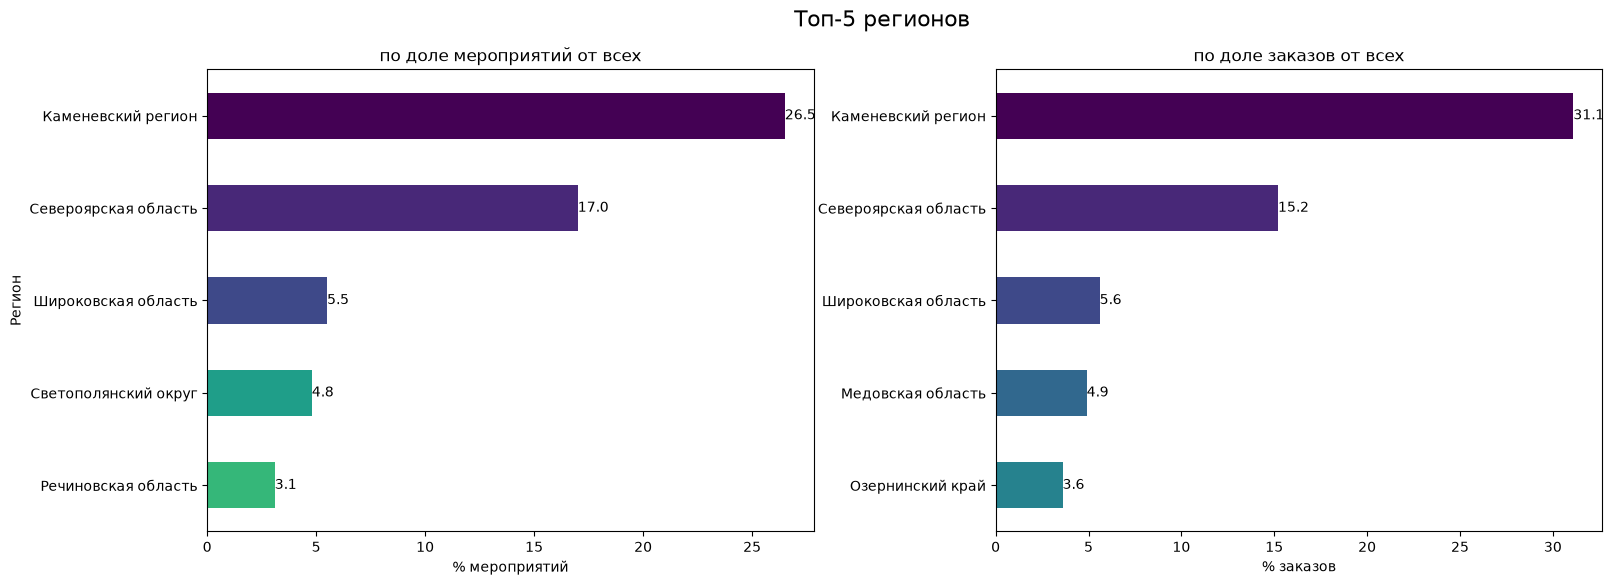

In [74]:
fig, (ax, ax2) = plt.subplots(ncols=2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.3)
plt.suptitle('Топ-5 регионов', fontsize=16)


region_event_plot = region_ev_5['event_share'].iloc[::-1].plot(kind='barh',
                             title='по доле мероприятий от всех',
                             x='LABEL',
                             legend=False,
                             ax=ax,
                             color = [color_dict[c] for c in region_ev_5['region_name'].iloc[::-1]])


region_order_plot = region_or_5['order_share'].iloc[::-1].plot(kind='barh',
                                    title='по доле заказов от всех',
                                    x='LABEL',
                                    ax=ax2,
                                    color = [color_dict[c] for c in region_or_5['region_name'].iloc[::-1]])

ax2.set_yticklabels(region_or_5['region_name'].iloc[::-1])
ax.set_yticklabels(region_ev_5['region_name'].iloc[::-1])
ax.set_ylabel('Регион')
ax.set_xlabel('% мероприятий')
ax2.set_xlabel('% заказов')

for i, (idx, row) in enumerate(region_ev_5.iloc[::-1].iterrows()):
    ax.text(
        x=row['event_share'],
        y=i,
        s=f"{row['event_share']}",
        va='center'
    )

for i, (idx, row) in enumerate(region_or_5.iloc[::-1].iterrows()):
    ax2.text(
        x=row['order_share'],
        y=i,
        s=f"{row['order_share']}",
        va='center'
    )

plt.show()

К ключевым по количеству мероприятий и заказам билетов на них без сомнений можно отнести два региона: Каменевский регион и Североярскую область, причем доля заказов на мероприятия в Каменевском регионе вдвое больше. Также третье место с большим отставанием от лидеров в обоих случаях заняла Широковская область.

Для каждого **билетного партнёра** посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов.

In [75]:
services = orders.groupby('service_name').agg({
    'event_id': 'nunique',
    'order_id': 'nunique',
    'revenue_rub': 'sum'
}).reset_index()
services['event_share'] = round(services['event_id'] / total_events_num * 100, 1)
services['order_share'] = round(services['order_id'] / total_orders_num * 100, 1)
services['revenue_share'] = round(services['revenue_rub'] / total_revenue_num * 100, 1)
services

,service_name,event_id,order_id,revenue_rub,event_share,order_share,revenue_share
0,Crazy ticket!,255,785,442295.69,1.1,0.3,0.3
1,Show_ticket,295,2043,1342809.07,1.3,0.7,0.9
2,Билет по телефону,19,83,67733.50,0.1,0.0,0.0
3,Билеты без проблем,4245,62403,23250557.95,19.0,21.9,16.4
4,Билеты в интернете,1,4,548.23,0.0,0.0,0.0
5,Билеты в руки,3525,40152,12893953.28,15.8,14.1,9.1
6,Быстробилет,252,1969,1502140.20,1.1,0.7,1.1
7,Быстрый кассир,20,372,381043.53,0.1,0.1,0.3
8,Весь в билетах,850,16012,15559653.87,3.8,5.6,11.0
9,Восьмёрка,143,1103,650515.81,0.6,0.4,0.5


Рассмотрим топ-10 партнеров по доле мероприятий:

In [76]:
services_events = services.sort_values(by='event_share', ascending=False).head(10)
services_events

,service_name,event_id,order_id,revenue_rub,event_share,order_share,revenue_share
21,Лови билет!,4863,40640,16295340.47,21.8,14.3,11.5
3,Билеты без проблем,4245,62403,23250557.95,19.0,21.9,16.4
5,Билеты в руки,3525,40152,12893953.28,15.8,14.1,9.1
25,Облачко,2323,26116,17926768.97,10.4,9.2,12.7
22,Лучшие билеты,1762,17706,2641787.93,7.9,6.2,1.9
24,Мой билет,1296,33490,19482245.00,5.8,11.8,13.8
30,Тебе билет!,1062,5131,2814176.07,4.8,1.8,2.0
26,Прачечная,1024,10161,4605770.18,4.6,3.6,3.3
8,Весь в билетах,850,16012,15559653.87,3.8,5.6,11.0
35,Яблоко,711,4931,3698619.31,3.2,1.7,2.6


по доле заказов:

In [77]:
services_orders = services.sort_values(by='order_share', ascending=False).head(10)
services_orders

,service_name,event_id,order_id,revenue_rub,event_share,order_share,revenue_share
3,Билеты без проблем,4245,62403,23250557.95,19.0,21.9,16.4
21,Лови билет!,4863,40640,16295340.47,21.8,14.3,11.5
5,Билеты в руки,3525,40152,12893953.28,15.8,14.1,9.1
24,Мой билет,1296,33490,19482245.00,5.8,11.8,13.8
25,Облачко,2323,26116,17926768.97,10.4,9.2,12.7
22,Лучшие билеты,1762,17706,2641787.93,7.9,6.2,1.9
8,Весь в билетах,850,16012,15559653.87,3.8,5.6,11.0
26,Прачечная,1024,10161,4605770.18,4.6,3.6,3.3
19,Край билетов,250,6002,6157696.30,1.1,2.1,4.3
30,Тебе билет!,1062,5131,2814176.07,4.8,1.8,2.0


и по доле принесенной выручки:

In [78]:
services_revenue = services.sort_values(by='revenue_share', ascending=False).head(10)
services_revenue

,service_name,event_id,order_id,revenue_rub,event_share,order_share,revenue_share
3,Билеты без проблем,4245,62403,23250557.95,19.0,21.9,16.4
24,Мой билет,1296,33490,19482245.00,5.8,11.8,13.8
25,Облачко,2323,26116,17926768.97,10.4,9.2,12.7
21,Лови билет!,4863,40640,16295340.47,21.8,14.3,11.5
8,Весь в билетах,850,16012,15559653.87,3.8,5.6,11.0
5,Билеты в руки,3525,40152,12893953.28,15.8,14.1,9.1
19,Край билетов,250,6002,6157696.30,1.1,2.1,4.3
26,Прачечная,1024,10161,4605770.18,4.6,3.6,3.3
13,Дом культуры,271,4278,4051832.33,1.2,1.5,2.9
35,Яблоко,711,4931,3698619.31,3.2,1.7,2.6


In [79]:
service_ev_5 = services_events.head(5).sort_values('event_share')
service_or_5 = services_orders.head(5).sort_values('order_share')
service_rev_5 = services_revenue.head(5).sort_values('revenue_share')

In [80]:
service_names = services_events['service_name'].unique()
cmap = plt.get_cmap('viridis', len(service_names))
color = [mcolors.to_hex(cmap(i)) for i in range(len(service_names))]
color_dict =  dict(zip(service_names, color))
patches = []
for service, color in color_dict.items():
    patches.append(mpatches.Patch(color=color, label=service))

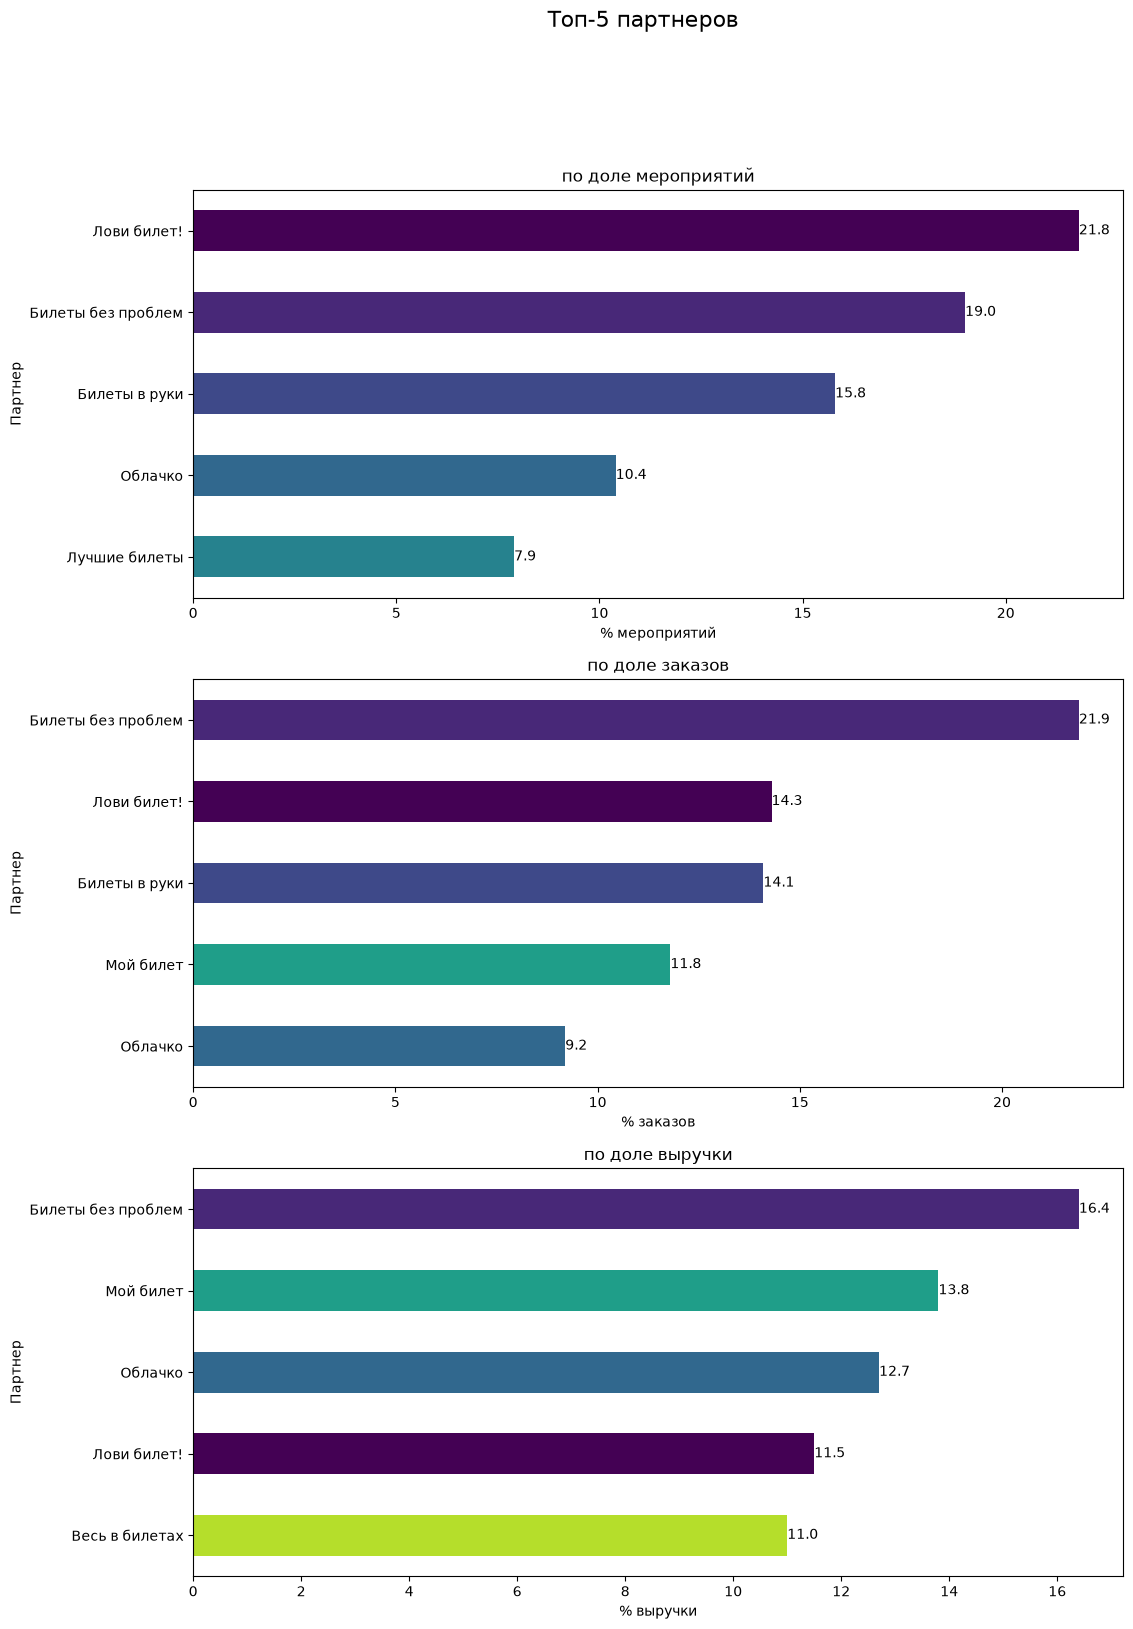

In [81]:
fig, (ax, ax2, ax3) = plt.subplots(ncols=1, nrows=3, figsize=(12, 18))
plt.suptitle('Топ-5 партнеров', fontsize=16)


services_events_plot = service_ev_5['event_share'].plot(kind='barh',
                             title='по доле мероприятий',
                             x='LABEL',
                             legend=False,
                             ax=ax,
                             color = [color_dict[c] for c in service_ev_5['service_name']])


services_orders_plot = service_or_5['order_share'].plot(kind='barh',
                                    title='по доле заказов',
                                    x='LABEL',
                                    ax=ax2,
                                    color = [color_dict[c] for c in service_or_5['service_name']])

services_revenue_plot = service_rev_5['revenue_share'].plot(kind='barh',
                                    title='по доле выручки',
                                    x='LABEL',
                                    ax=ax3,
                                    color = [color_dict[c] for c in service_rev_5['service_name']])

ax.set_yticklabels(service_ev_5['service_name'])
ax2.set_yticklabels(service_or_5['service_name'])
ax3.set_yticklabels(service_rev_5['service_name'])
ax.set_ylabel('Партнер')
ax2.set_ylabel('Партнер')
ax3.set_ylabel('Партнер')
ax.set_xlabel('% мероприятий')
ax2.set_xlabel('% заказов')
ax3.set_xlabel('% выручки')

for i, (idx, row) in enumerate(service_ev_5.iterrows()):
    ax.text(
        x=row['event_share'],
        y=i,
        s=f"{row['event_share']}",
        va='center'
    )

for i, (idx, row) in enumerate(service_or_5.iterrows()):
    ax2.text(
        x=row['order_share'],
        y=i,
        s=f"{row['order_share']}",
        va='center'
    )

for i, (idx, row) in enumerate(service_rev_5.iterrows()):
    ax3.text(
        x=row['revenue_share'],
        y=i,
        s=f"{row['revenue_share']:.1f}",
        va='center'
    )

plt.show()

К ключевым партнерам, попавшим в топ-5 по количеству мероприятий, заказов и выручке одновременно, можно отнести операторов "Лови билет!", "Билеты без проблем", "Облачко". Кроме того, большой интерес представляет сервис "Мой билет", занимающий второе место по выручке, несмотря на четвертое место по количеству заказов и всего шестое по количеству мероприятий. "Билеты в руки" занимает третье место по количеству мероприятий и заказов, но приносит меньше выручки (6 место).

**Промежуточные выводы:**
- ключевыми регионами являются Каменевский регион (26,5% мероприятий и 31,1% заказов) и Североярская область (17% и 15,2% соответственно). В сумме в них проходит 43,6% мероприятий, на которые оформляются 46,4% заказов билетов;
- с большой долей осторожности представляющей интерес можно назвать Широковскую область с 5,5% мероприятий и 5,6% заказов. Лучше понять перспективы развития досуговых мероприятий и площадок в регионе поможет дополнительный анализ динамики за более долгий период;
- к ключевым партнерам по количеству мероприятий, заказов и выручке относятся операторы  "Лови билет!" (21,8% мероприятий, 14,3% заказов и 11,5% выручки), "Билеты без проблем" (19%, 21,9%, 16,4% соответственно), "Облачко" (10,4%, 9,2%, 12,7%);
- большой интерес может представлять развитие партнерства с оператором "Мой билет", доля выручки с продаж билетов (13,8%) которого превышает долю заказов (11,8%) и мероприятий (5,8%);
- сервис "Билеты в руки" приносит меньше выручки (9,1%), чем ожидается при высокой доле мероприятий (15,8%) и заказов (14,1%). Рекомендуется выяснение причин.

# 4. Статистический анализ данных<a class="anchor" id="stats"></a>

###  Среднее количество заказов пользователя по типам устройств<a class="anchor" id="num"></a>

Проверим статистически гипотезу о наличии различия в среднем количестве заказов на пользователя мобильного приложения и стационарных устройств осенью 2024 года.

Для этого используем одностороннюю проверку гипотезы с двумя выборками:

- **Нулевая гипотеза H₀:** среднее количество заказов на пользователя приложения не превышает таковое на пользователя мстационарных устройств.

- **Альтернативная гипотеза H₁:** среднее количество заказов на пользователя мобильного приложения выше, чем на пользователя стационарных устройств, и это различие статистически значимо.

Перед проведением статистического теста подготовим данные и изучим статистики.

Проверим наличие пользователей, оформлявших заказы обоими способами в течение осени.

In [109]:
mobile_users_full = autumn[autumn['device_type_canonical']=='mobile']['user_id']
desktop_users_full = autumn[autumn['device_type_canonical']=='desktop']['user_id']
intersection = list(set(mobile_users_full) & set(desktop_users_full))
len(intersection)

3224

Найдено 3224 пересечения. Для обеспечения независимости выборок необходимо исключить записи о заказах таких пользователей из дальнейшего анализа.

In [84]:
test_data = autumn[~autumn['user_id'].isin(intersection)]

Узнаем размер и статистику распределения количества заказов на пользователя получившихся тестовых групп:

In [85]:
user_order = test_data.groupby('user_id').agg({
    'order_id': 'nunique',
    'device_type_canonical': 'max'
}).reset_index()

In [86]:
user_order.groupby('device_type_canonical')['order_id'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
device_type_canonical,,,,,,,,
desktop,1618.0,1.97,3.06,1.0,1.0,1.0,2.0,56.0
mobile,10900.0,2.86,4.10,1.0,1.0,2.0,3.0,123.0


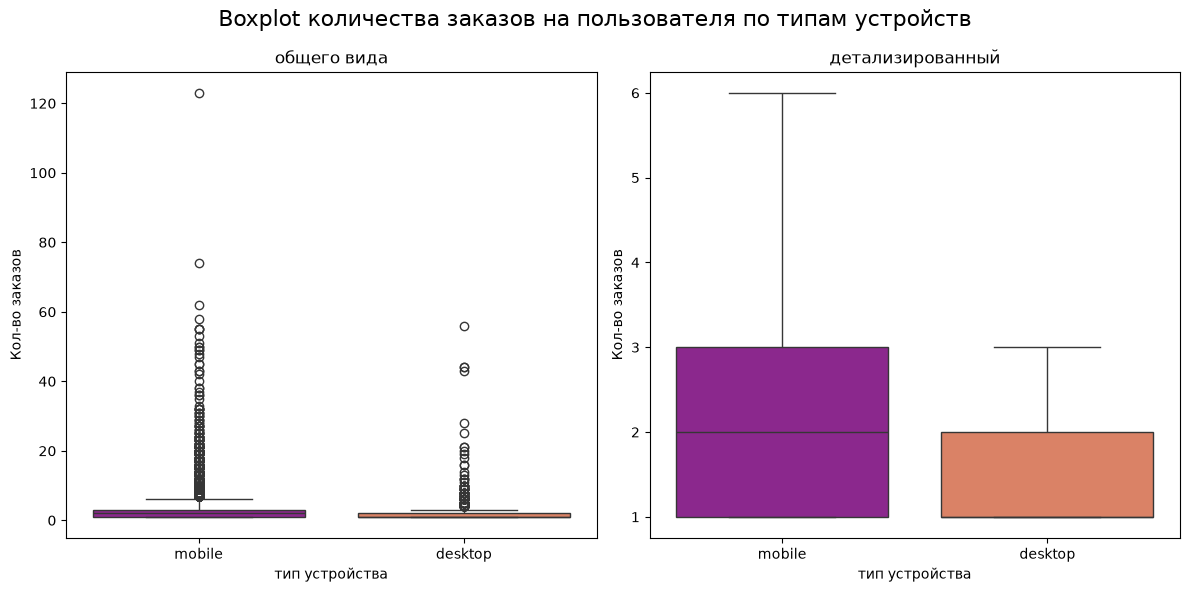

In [115]:
plt.figure(figsize=(12, 6))
plt.suptitle('Boxplot количества заказов на пользователя по типам устройств', fontsize=16)

plt.subplot(1, 2, 1)
sns.boxplot(x='device_type_canonical',
            y='order_id',
            hue='device_type_canonical',
            data=user_order,
            palette='plasma')
plt.title('общего вида')
plt.ylabel('Кол-во заказов')
plt.xlabel('тип устройства')

plt.subplot(1, 2, 2)
sns.boxplot(x='device_type_canonical',
            y='order_id',
            hue='device_type_canonical',
            data=user_order,
            showfliers=False,
            palette='plasma')
plt.title('детализированный')
plt.ylabel('Кол-во заказов')
plt.xlabel('тип устройства')

plt.tight_layout()
plt.show()

Среднее значение заказов на пользователя выше для мобильного приложения, что говорит в пользу альтернативной гипотезы. Для проверки статистической значимости этого различия необходимо выбрать и провести статистический тест.

Группы различаются по размеру (1623 пользователя стационарных устройств и 10948 мобильных), но достаточны по размеру для проведения t-теста Уэлча потому что центральная предельная теорема при размере выборки > 30 обеспечивает нормальность распределения средних. Кроме того, этот тест позволяет не проводить дополнительную проверку равенства дисперсий.

Проведем тест:

In [88]:
orders_mobile = user_order[user_order['device_type_canonical'] == 'mobile']['order_id']
orders_desktop = user_order[user_order['device_type_canonical'] == 'desktop']['order_id']

alpha = 0.05 

stat_ttest, p_value_ttest = ttest_ind(
    orders_mobile, 
    orders_desktop, 
    alternative='greater',
    equal_var=False
) 

if p_value_ttest > alpha:
    print(f'p-value теста Уэлча = {p_value_ttest} > alpha = {alpha}')
    print('Нулевая гипотеза находит подтверждение:\ncреднее количество заказов на пользователя мобильных устройств не превышает')
    print('cреднее количество заказов на пользователя стационарных устройств.')
else:
    print(f'p-value теста Уэлча = {p_value_ttest} < alpha = {alpha}')
    print('Нулевая гипотеза не находит подтверждения:\ncреднее кол-во заказов на пользователя мобильных устройств больше.')

p-value теста Уэлча = 5.956981224954014e-25 < alpha = 0.05
Нулевая гипотеза не находит подтверждения:
cреднее кол-во заказов на пользователя мобильных устройств больше.


Тест подтверждает статистическую значимость различия и позволяет подтвердить альтернативную теорию: среднее количество заказов на пользователя мобильного приложения выше, чем на пользователя стационарных устройств.

###  Среднее время между заказами пользователей по типам устройств<a class="anchor" id="interval"></a>

Проверим статистически гипотезу о наличии различия в среднем времени между заказами на пользователя мобильного приложения и стационарных устройств осенью 2024 года.

Для этого используем одностороннюю проверку гипотезы с двумя выборками:

**Нулевая гипотеза H₀:** среднее время между заказами на пользователя мобильного приложения не превышает таковое чем на пользователя стационарных устройств.

**Альтернативная гипотеза H₁:** среднее время между заказами на пользователя мобильного приложения больше, и это различие статистически значимо.

Перед проведением статистического теста подготовим данные и изучим статистики.

Исключим из анализа заказы с пропусками а столбце со значением количества дней, прошедших с момента предыдущего заказа пользователя `days_since_prev`. Это записи о первых заказах и они не дают никакой информации об исследуемой метрике.

In [89]:
test_data = test_data[~test_data['days_since_prev'].isna()]

Рассмотрим статистику распределения времени между заказами:

In [90]:
user_interval = test_data.groupby('user_id').agg({
    'days_since_prev': 'mean',
    'device_type_canonical': 'max'
}).reset_index()

In [91]:
user_interval.groupby('device_type_canonical')['days_since_prev'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
device_type_canonical,,,,,,,,
desktop,896.0,31.31,36.44,0.0,0.00,16.5,52.62,146.0
mobile,7035.0,25.16,30.15,0.0,2.81,14.0,36.00,148.0


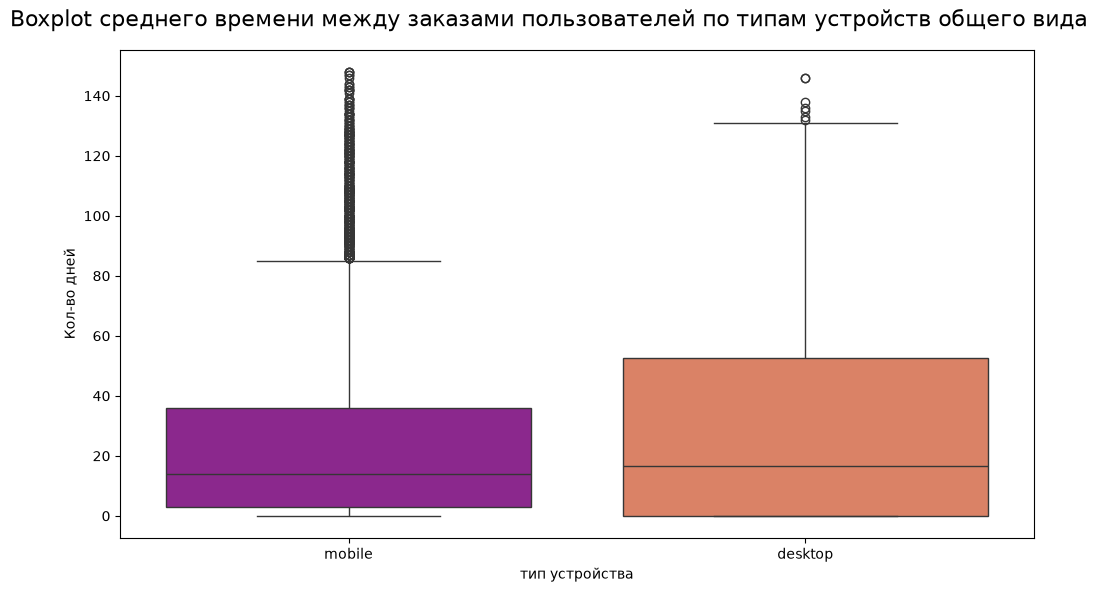

In [116]:
plt.figure(figsize=(10, 6))
plt.suptitle('Boxplot среднего времени между заказами пользователей по типам устройств общего вида', fontsize=16)

sns.boxplot(x='device_type_canonical',
            y='days_since_prev',
            hue='device_type_canonical',
            data=user_interval,
            palette='plasma')
plt.ylabel('Кол-во дней')
plt.xlabel('тип устройства')

plt.tight_layout()
plt.show()

Среднее время между заказами выше у пользователей стационарных устройств (31,44), чем мобильного приложения (25,26). Это говорит против альтернативной гипотезы. Проверим статистически, вероятно ли, что это результат случайных колебаний и при большем количестве данных результат будет стремиться к тому, что значение метрики для мобильных устройств станет выше, чем для стационарных. Для проверки также был выбран t-тест Уэлча.

In [93]:
interval_mobile = user_interval[user_interval['device_type_canonical'] == 'mobile']['days_since_prev']
interval_desktop = user_interval[user_interval['device_type_canonical'] == 'desktop']['days_since_prev']

alpha = 0.05 

stat_ttest, p_value_ttest = ttest_ind(
    interval_mobile, 
    interval_desktop, 
    alternative='greater',
    equal_var=False
) 

if p_value_ttest > alpha:
    print(f'p-value теста Уэлча = {round(p_value_ttest, 2)} > alpha = {alpha}')
    print('Нулевая гипотеза находит подтверждение:')
    print('среднее время между заказами у пользователей мобильных устройств не превышает таковое у пользователей стационарных.')
else:
    print(f'p-value теста Уэлча = {round(p_value_ttest, 2)} < alpha = {alpha}')
    print('Нулевая гипотеза не находит подтверждения:')
    print('среднее время между заказами у пользователей мобильных устройств больше.')

p-value теста Уэлча = 1.0 > alpha = 0.05
Нулевая гипотеза находит подтверждение:
среднее время между заказами у пользователей мобильных устройств не превышает таковое у пользователей стационарных.


Результат теста не позволяет подтвердить альтернативную гипотезу. 

# 5. Общий вывод и рекомендации<a class="anchor" id="summary"></a>

Анализ производился на данных о бронировании билетов на сервисе Яндекс.Афиша за период с 1 июня по 31 октября 2024 года. Была выполнена предобработка данных: объединение датафреймов, удаление дубликатов, коррекция типов, добавление новых столбцов и приведение к общей валюте. В результате этих действий дальнейший анализ проводился на датафрейме, состоящем из 287574 строк и 30 столбцов.

**Выводы:**
- количество заказов стабильно увеличивается на протяжении всего исследуемого периода, причем осенью темп роста значительно выше;
- в предпочтениях пользователей заметна сезонность: так, осенью растет количество заказов на театральные представления и спортивные мероприятия, а популярность концертов несколько снижается;
- кроме того, с наступлением осень повышается доля заказов на детские и семейные мероприятия;
- распределение пользователей по типам устройств остается практически неизменным и около 80% всех заказов оформляются через мобильное приложение;
- наблюдается отрицательная динамика выручки с одного билета для категорий театра, ёлок и концертов;
- осенью 2024 г. количество активных пользователей стабильно росло;
- в осениие месяцы было два дня рекордных продаж: 3 сентября и 1 октября. В эти дни активно продавались билеты со стоимостью ниже типичной;
- в разрезе недельной динамики осенью наблюдается рост активности пользователей в первой половине недели и спад во второй;
- ключевыми реионами являются Каменевский регион и Североярская область. В них проходит более 43% мероприятий, заказы билетов на которые составляют 46% от всех;
- к ключевым партнерам по количеству мероприятий, заказов и выручке относятся операторы "Лови билет!", "Билеты без проблем", "Облачко". Также заметную долю выручки приносит сотрудничество с оператором "Мой билет";
- статистически подтверждена гипотеза о том, что среднее количество заказов на пользователя мобильного приложения выше, чем на пользователя стационарных устройств;
- гипотеза о том, что среднее время между заказами пользователя мобильного приложения больше, не нашла подтверждения.

**Рекомендации:**
- сделать приоритетом развитие мобильного приложения, а не сайта;
- проведение маркетинговых кампаний по регионам. Обратить внимание на Широковскую область, по возможности провести исследование динамики активности в регионе на более продолжительном периоде;
- учет сезонных тенденций при проведении маркетинговых кампаний: сделать акцент на театрах и спортивных мероприятиях осенью;
- расширение сотрудничества с оператором "Мой билет";
- выяснение причин относительно невысокой выручки от работы с оператором "Билеты в руки" при высокой доле мероприятий и заказов;
- разработка системы персональных рекомендаций;
- анализ причин топовых продаж осенью 2024 г.: 3 сентября и 1 октября.